# **Preparation Notebook**



---
## Setup Environment

In [2]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT2",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.42 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
Mounted at /content/gdrive

You can now save your data files in: /content/gdrive/MyDrive/36106/assignment/AT2/data


---
## Student Information

In [3]:
student_name = "SUSHRUTA GANGADHAR PATIL"
student_id = "26273312"

In [4]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h1", key='student_name', value=student_name)

In [5]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

### 0.b Import Packages

In [6]:
# DO NOT MODIFY THE CODE IN THIS CELL
import pandas as pd
import altair as alt

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_classif, chi2
from sklearn.preprocessing import LabelEncoder, StandardScaler

---
## A. Feature Selection


## A.0 # Load Data

In [8]:
# DO NOT MODIFY THE CODE IN THIS CELL
try:
  df = pd.read_csv(at.folder_path / "disease.csv")
except Exception as e:
  print(e)

### A.1 Approach 1 : EDA Visual Analysis

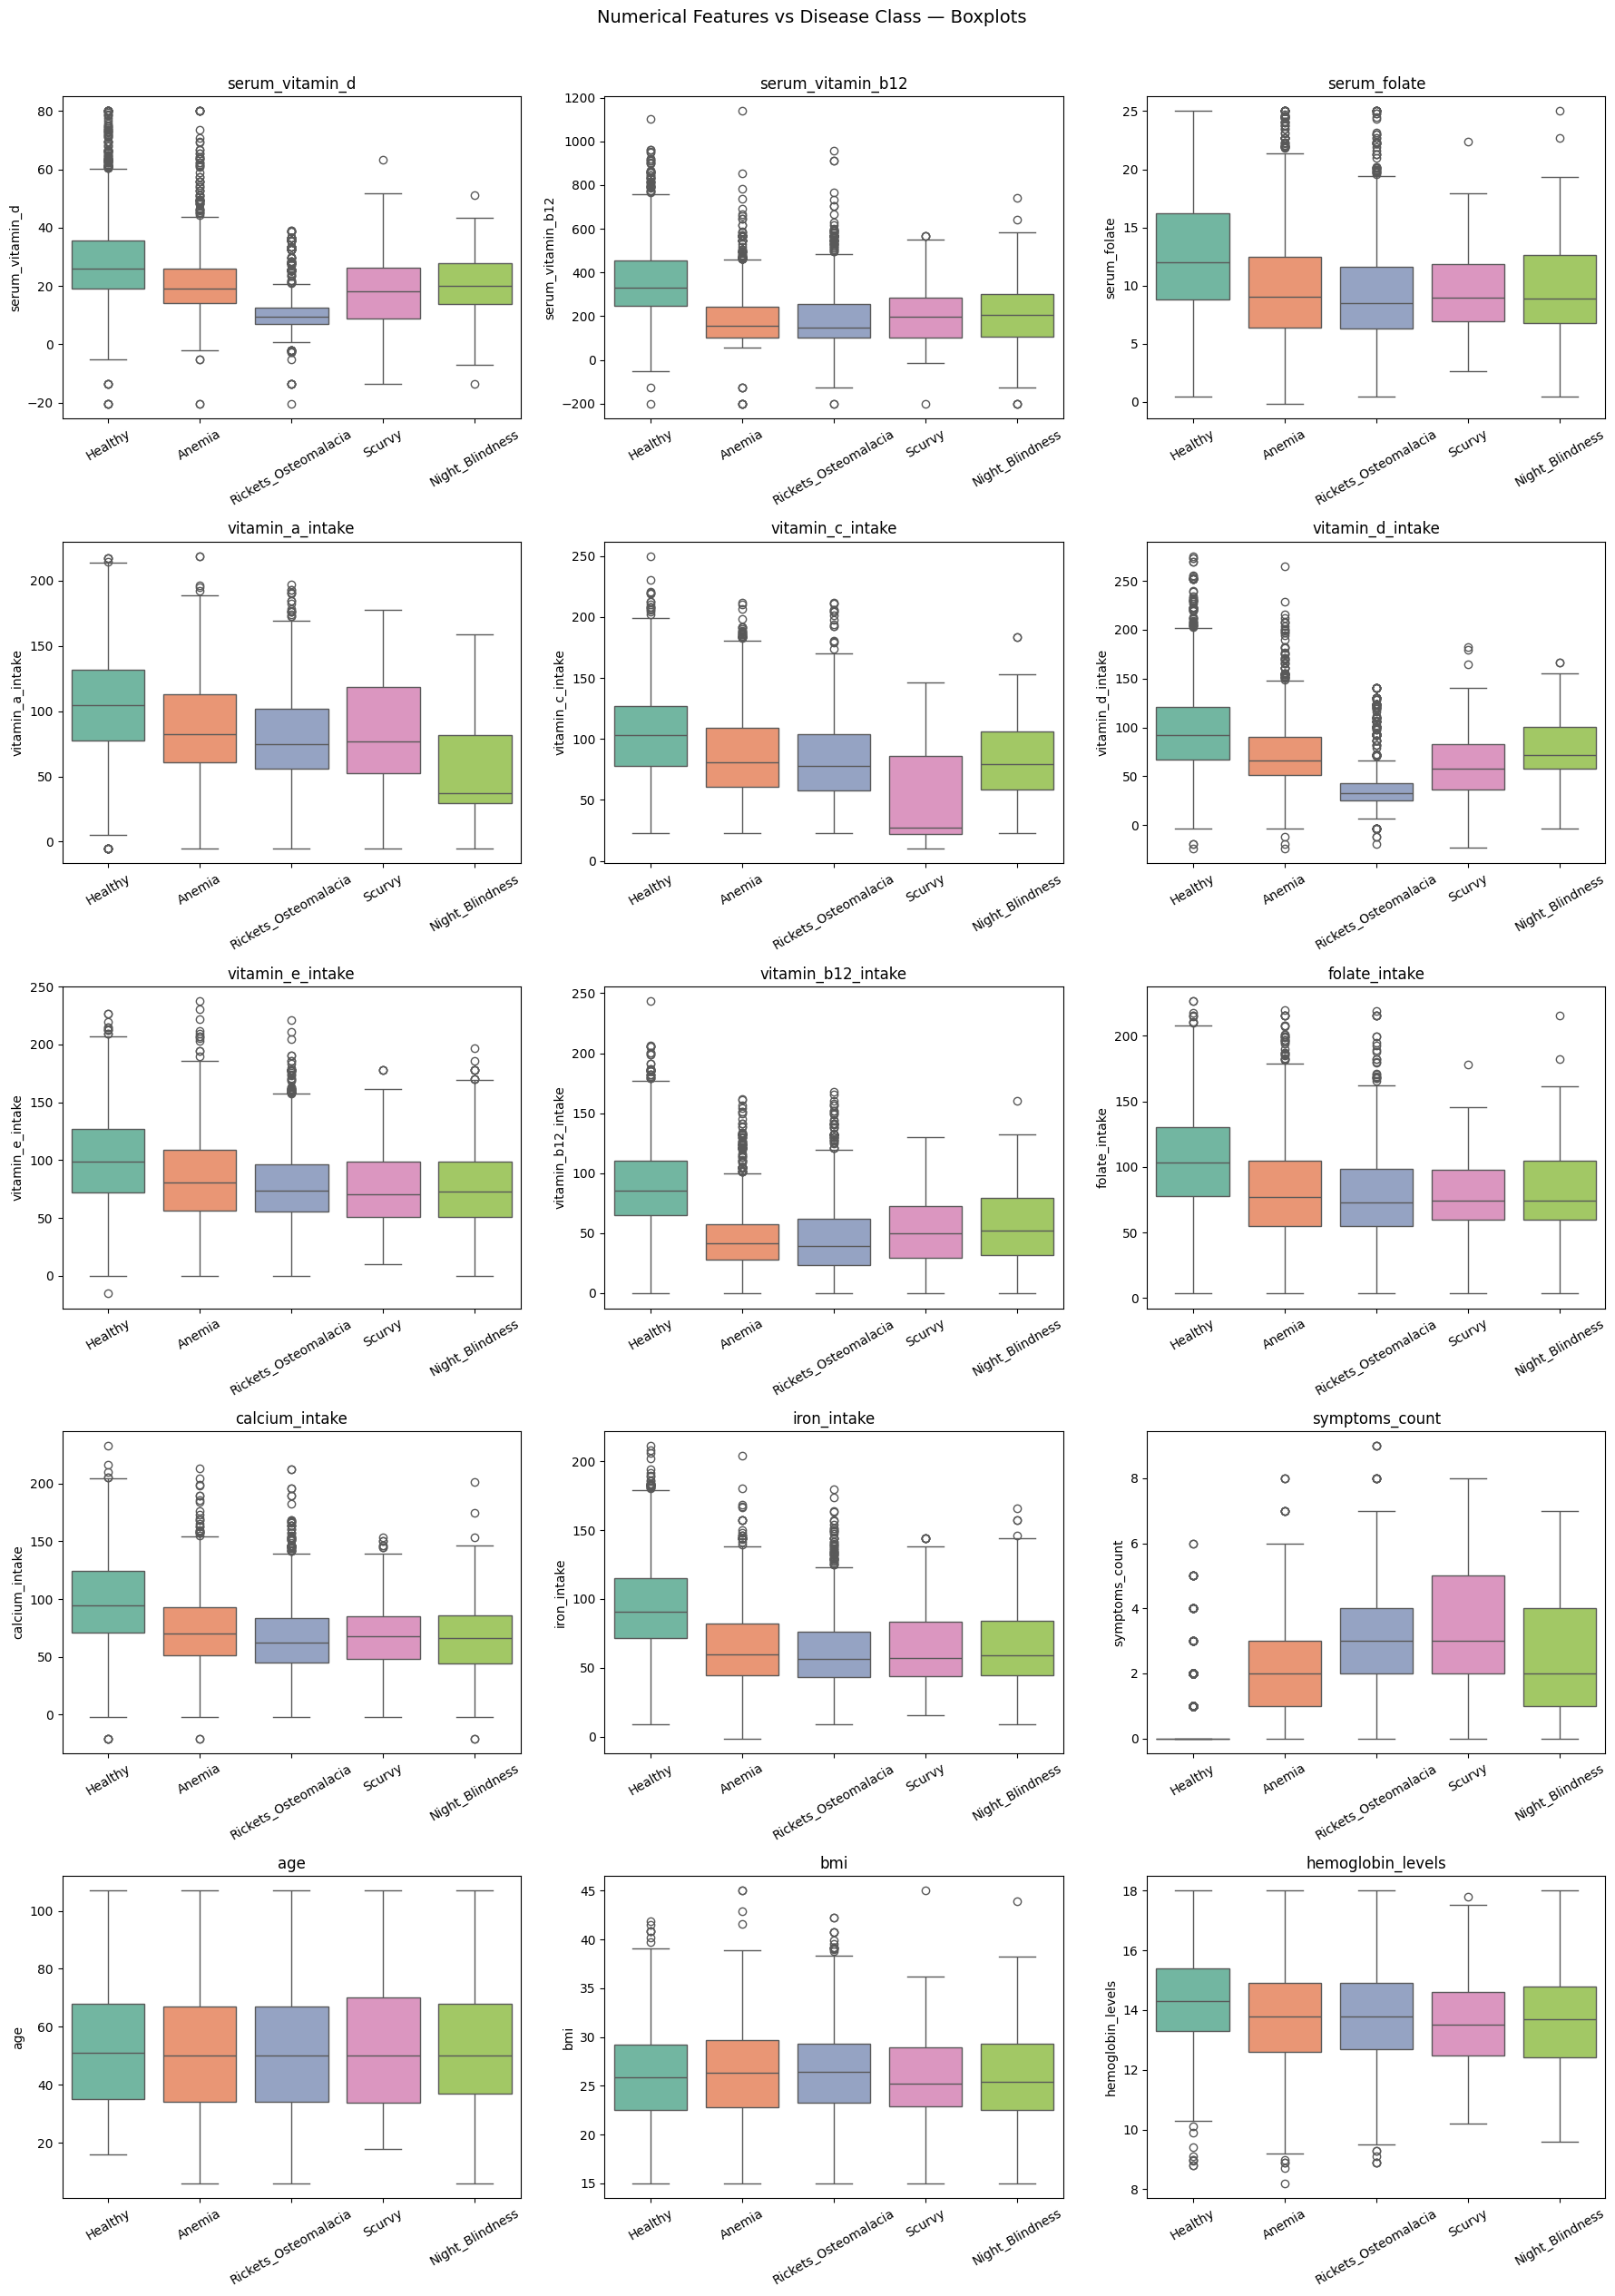

In [9]:
# numerical columns to visually assess for class separation
num_cols = [
    'serum_vitamin_d', 'serum_vitamin_b12', 'serum_folate',
    'vitamin_a_intake', 'vitamin_c_intake', 'vitamin_d_intake',
    'vitamin_e_intake', 'vitamin_b12_intake', 'folate_intake',
    'calcium_intake', 'iron_intake', 'symptoms_count',
    'age', 'bmi', 'hemoglobin_levels'
]

# boxplots for all numerical features vs disease class
fig, axes = plt.subplots(5, 3, figsize=(18, 25))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x='disease_diagnosis', y=col,
                ax=axes[i], palette='Set2')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)

fig.suptitle('Numerical Features vs Disease Class — Boxplots', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

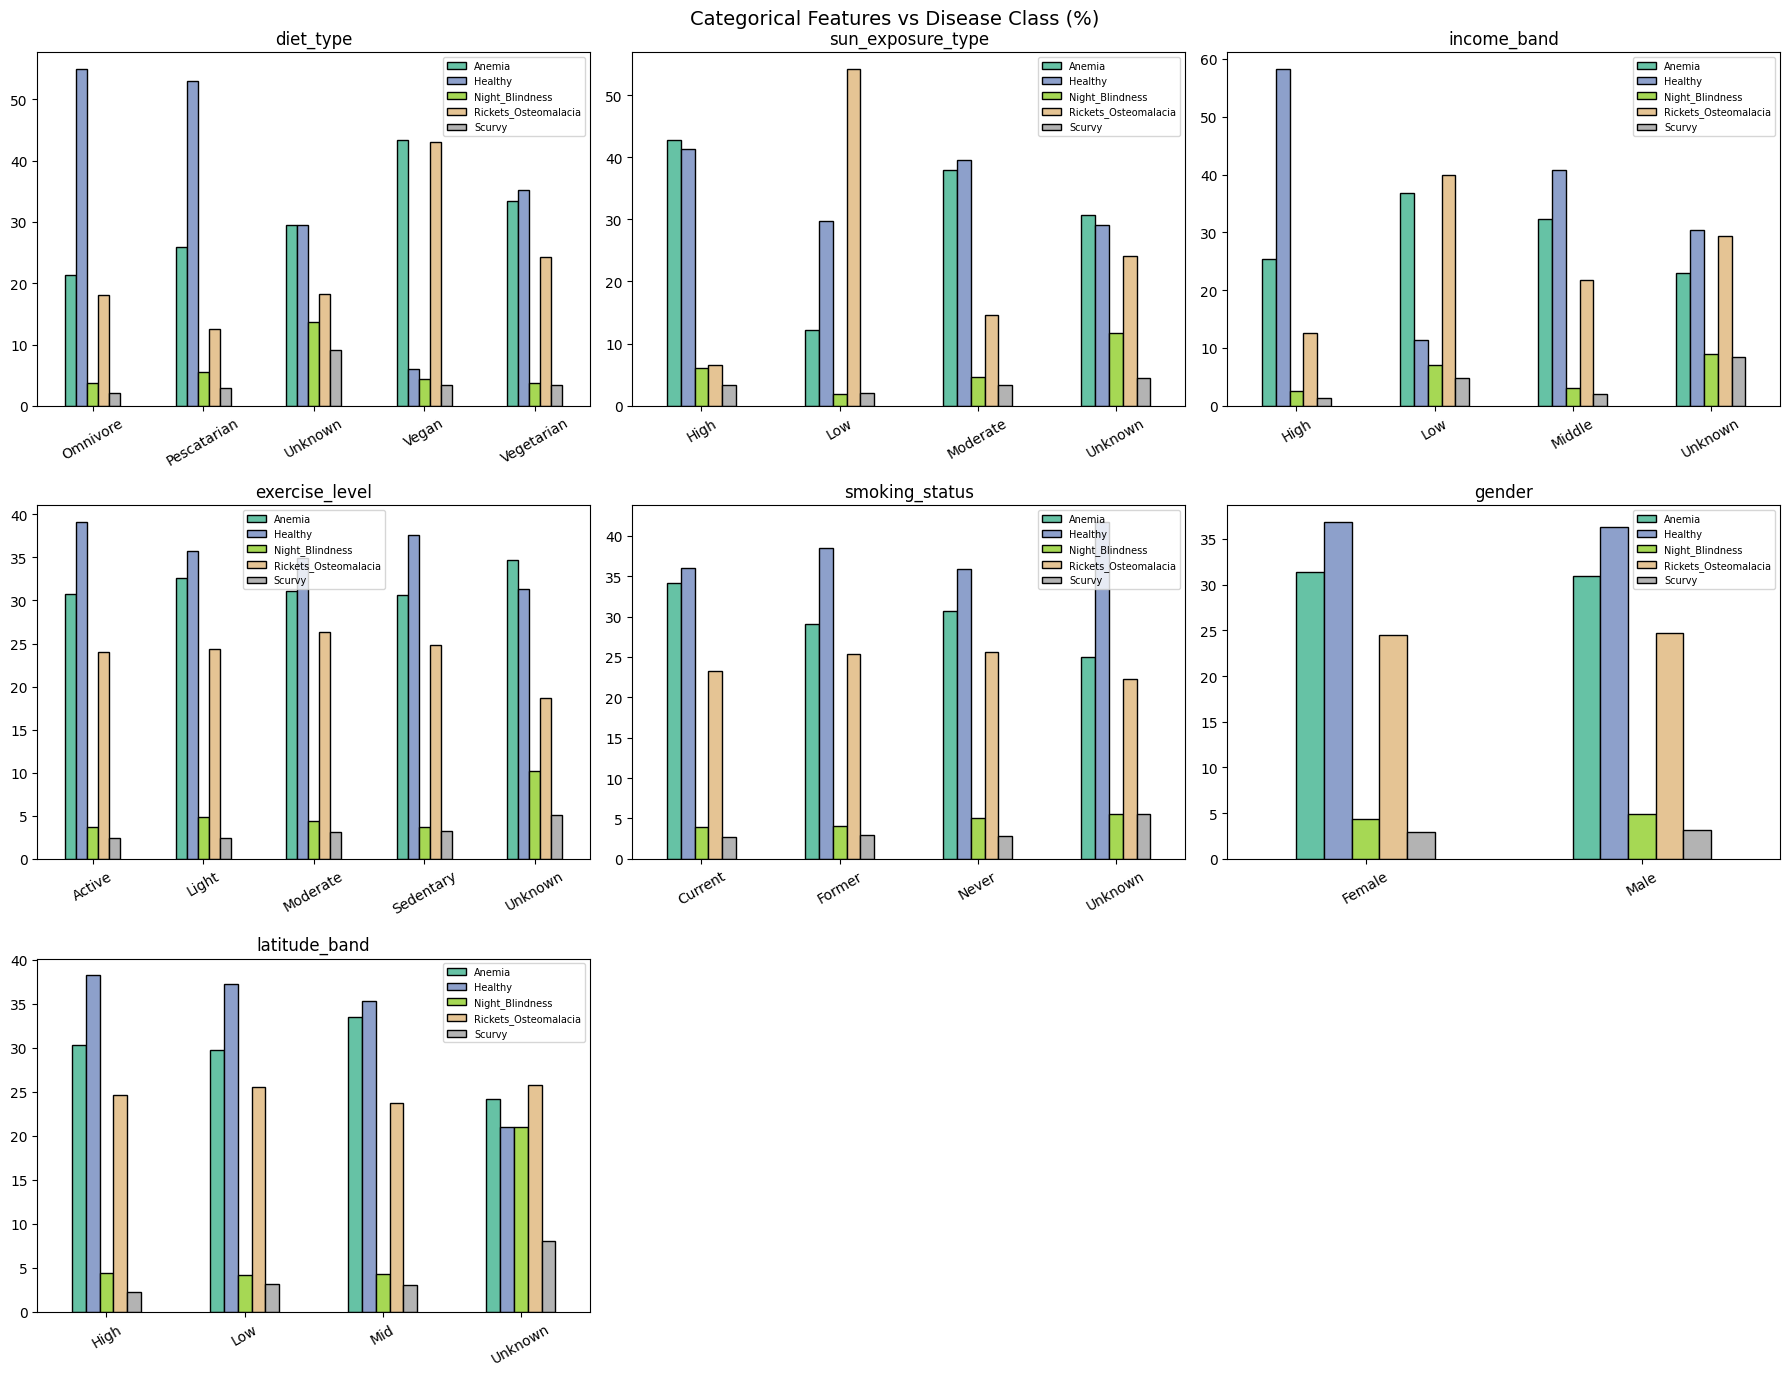

In [10]:
# categorical and binary columns to assess via crosstabs
cat_cols = [
    'diet_type', 'sun_exposure_type', 'income_band',
    'exercise_level', 'smoking_status', 'gender', 'latitude_band'
]

# crosstab plots show proportion of each disease class within each category
# a flat distribution across categories means the feature has no signal
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    crosstab = pd.crosstab(df[col], df['disease_diagnosis'],
                           normalize='index') * 100
    crosstab.plot(kind='bar', ax=axes[i], colormap='Set2', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(fontsize=7)

axes[7].set_visible(False)
axes[8].set_visible(False)

fig.suptitle('Categorical Features vs Disease Class (%)', fontsize=14)
plt.tight_layout()
plt.show()

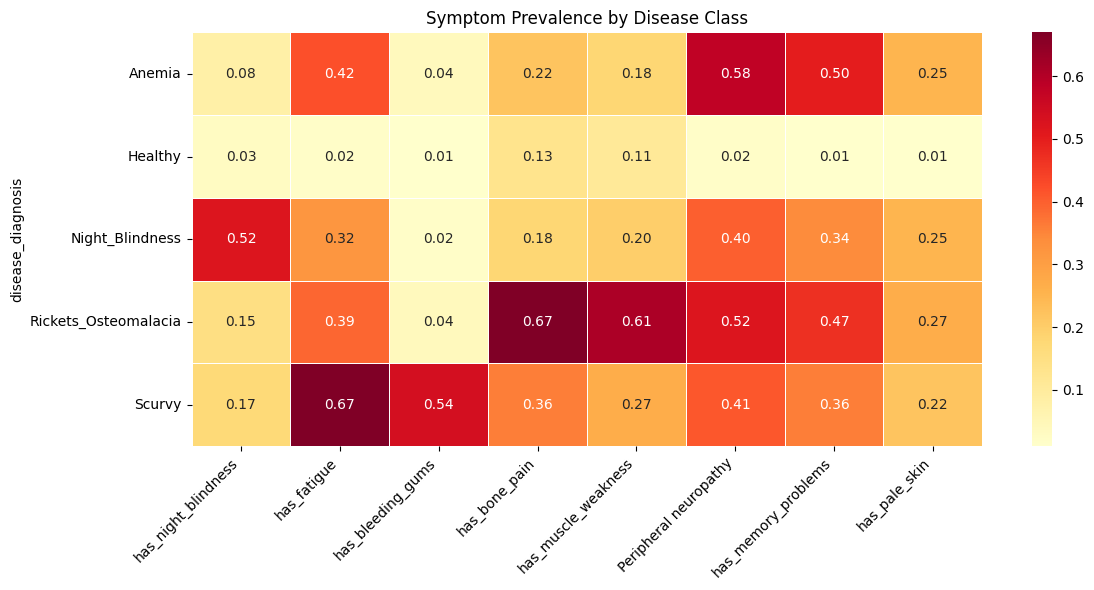

In [11]:
# symptom columns: mean prevalence per disease class shows which symptoms are specific to which disease
symptom_cols = [
    'has_night_blindness', 'has_fatigue', 'has_bleeding_gums',
    'has_bone_pain', 'has_muscle_weakness', 'Peripheral neuropathy',
    'has_memory_problems', 'has_pale_skin'
]

plt.figure(figsize=(12, 6))
sns.heatmap(
    df.groupby('disease_diagnosis')[symptom_cols].mean().round(2),
    annot=True,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5
)
plt.title('Symptom Prevalence by Disease Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:
feature_selection_1_insights = """

The first approach used visual analysis of all features against the target
variable disease_diagnosis across five classes: Healthy, Anemia,
Rickets_Osteomalacia, Night_Blindness and Scurvy.

For numerical features, boxplots were used to compare distributions across
all five disease classes. Features where boxes sat in clearly different
positions across classes were retained. Features where boxes overlapped
almost entirely were flagged for removal.

serum_vitamin_d showed the strongest separation. The Rickets_Osteomalacia
box sits far below all other classes with very little overlap, confirming
it as the primary serum indicator for that disease. vitamin_c_intake showed
a very clear drop for Scurvy patients whose box sits well below all other
classes. vitamin_a_intake showed the same pattern for Night_Blindness
patients. vitamin_b12_intake showed clear separation between Healthy and
all disease classes particularly Anemia. symptoms_count showed one of the
clearest separations overall with the Healthy box sitting at 0 while all
disease classes sit between 2 and 3. These features are retained.

serum_vitamin_b12, serum_folate, folate_intake, calcium_intake and
iron_intake all showed Healthy patients sitting higher than disease classes
but with considerable overlap between the disease classes themselves.
These features contribute to separating Healthy from diseased patients
and are retained despite their limited ability to distinguish between
individual disease classes.

age and bmi showed near identical box positions across all five classes
with no separation whatsoever in this dataset. hemoglobin_levels showed
near complete overlap across all classes with only marginal differences.
vitamin_e_intake was the only intake feature where all five class boxes
sat at almost identical positions. These four features are dropped as
they provide no discriminative signal in this dataset.

For categorical features, crosstab plots showed the proportion of each
disease class within each category value. diet_type showed the strongest
signal where Vegan patients had almost no Healthy representation and were
dominated by Anemia and Rickets, while Omnivore and Pescatarian patients
were predominantly Healthy. sun_exposure_type showed that Low sun patients
were dominated by Rickets while High sun patients were mostly Healthy and
Anemia, consistent with the role of sunlight in vitamin D synthesis.
income_band showed that High income patients were predominantly Healthy
while Low income patients were dominated by Rickets and Anemia. These
three features are retained.

exercise_level, smoking_status, gender and latitude_band all showed near
identical disease class proportions across all their category values in
this dataset. The bar heights within each category were consistent
regardless of the category value meaning these features provided no
discriminative signal for disease classification here.

The symptom heatmap confirmed strong associations between specific symptoms
and disease classes. has_bleeding_gums was present in 54 percent of Scurvy
patients and below 4 percent for all other classes making it the most
specific symptom in the dataset. has_bone_pain was present in 67 percent
of Rickets patients compared to 13 percent for Healthy. has_night_blindness
was present in 52 percent of Night_Blindness patients compared to 3 percent
for Healthy. has_fatigue, Peripheral neuropathy, has_memory_problems and
has_pale_skin are spread across multiple disease classes but all show clear
separation between Healthy patients and all disease classes. All 8 symptom
columns are retained.

"""

In [13]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_1_insights', value=feature_selection_1_insights)

### A.2 Approach 2 : Correlation Analysis

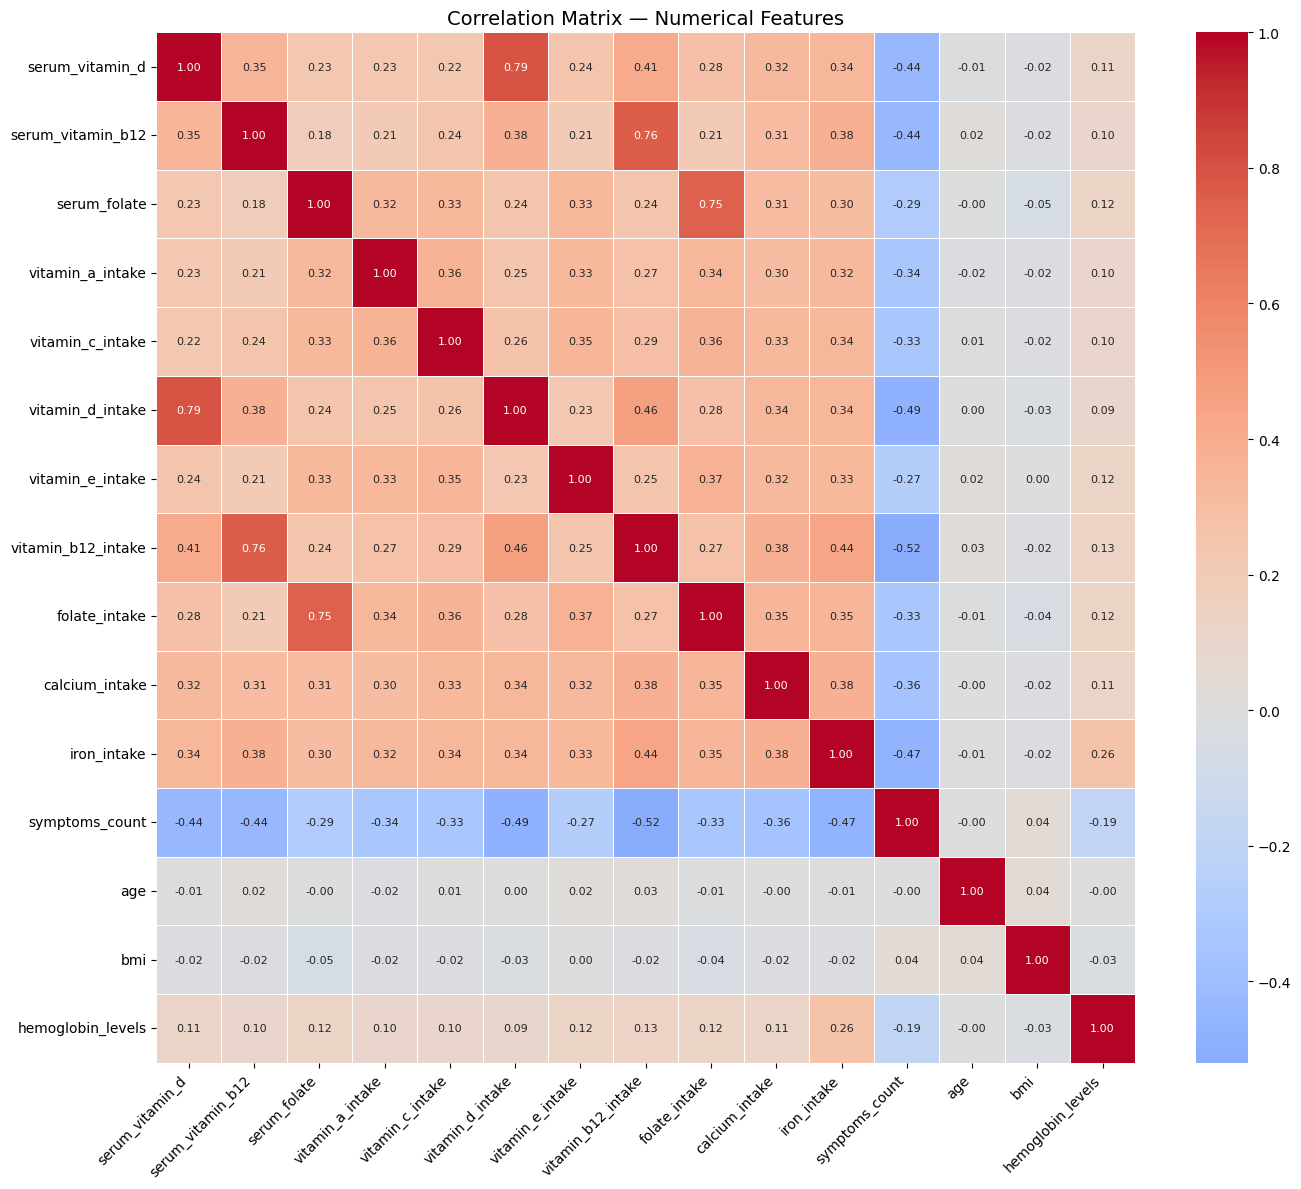

In [14]:
'''correlation matrix of all numerical features
used to assess two things:
1. which features have near zero correlation with everything - candidates for removal
2. which feature pairs are highly correlated with each other - multicollinearity check'''

num_cols = [
    'serum_vitamin_d', 'serum_vitamin_b12', 'serum_folate',
    'vitamin_a_intake', 'vitamin_c_intake', 'vitamin_d_intake',
    'vitamin_e_intake', 'vitamin_b12_intake', 'folate_intake',
    'calcium_intake', 'iron_intake', 'symptoms_count',
    'age', 'bmi', 'hemoglobin_levels'
]

corr_matrix = df[num_cols].corr().round(2)

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': 8}
)
plt.title('Correlation Matrix — Numerical Features', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [15]:
'''isolate the highest correlated pairs above 0.70 threshold
to explicitly identify and discuss multicollinearity'''
high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i + 1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) >= 0.70:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                round(val, 2)
            ))

print("Feature pairs with correlation >= 0.70:")
print()
for pair in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {pair[0]}  <-->  {pair[1]}  :  {pair[2]}")

Feature pairs with correlation >= 0.70:

  serum_vitamin_d  <-->  vitamin_d_intake  :  0.79
  serum_vitamin_b12  <-->  vitamin_b12_intake  :  0.76
  serum_folate  <-->  folate_intake  :  0.75


In [16]:
'''check correlation of all numerical features with each other
to identify features with near zero correlation across the board'''
print("Mean absolute correlation per feature (excluding self-correlation):")
print()

mean_abs_corr = corr_matrix.abs().mean().sort_values()
for feat, val in mean_abs_corr.items():
    print(f"  {feat}: {round(val, 3)}")

Mean absolute correlation per feature (excluding self-correlation):

  age: 0.078
  bmi: 0.091
  hemoglobin_levels: 0.172
  vitamin_e_intake: 0.291
  vitamin_a_intake: 0.294
  vitamin_c_intake: 0.303
  serum_folate: 0.313
  serum_vitamin_b12: 0.321
  calcium_intake: 0.322
  serum_vitamin_d: 0.333
  folate_intake: 0.337
  vitamin_d_intake: 0.345
  iron_intake: 0.352
  vitamin_b12_intake: 0.365
  symptoms_count: 0.367


In [17]:
feature_selection_2_insights = """

The second approach used correlation analysis on all numerical features to
assess two things: which features have near zero correlation across the
board suggesting they carry little information, and which feature pairs are
highly correlated with each other which raises multicollinearity concerns
for certain model types.

Three high correlation pairs were identified above the 0.70 threshold.
vitamin_d_intake and serum_vitamin_d correlate at 0.79. vitamin_b12_intake
and serum_vitamin_b12 correlate at 0.76. folate_intake and serum_folate
correlate at 0.75. In linear models these correlations would be problematic
as they inflate coefficient variance. However the experiments planned here
use tree based models which are not affected by multicollinearity since they
split on one feature at a time. Both columns in each pair are therefore
retained because they represent different measurements of the same
underlying deficiency. The intake column captures what the patient consumes
in their diet as a percentage of RDA. The serum column captures what
actually ended up in their bloodstream. A patient can have adequate intake
but low serum levels or vice versa and the two columns together tell a more
complete story than either alone.

symptoms_count showed strong negative correlations with vitamin intake
features as expected. The strongest was -0.52 with vitamin_b12_intake
followed by -0.49 with vitamin_d_intake and -0.47 with iron_intake. This
confirms the clinical logic that lower vitamin intake leads to more symptoms
and validates both symptoms_count and the intake features as meaningful
columns.

age showed near zero mean absolute correlation across all features
confirming what the boxplots showed. It carries no linear relationship
with any other feature in this dataset. bmi showed the same pattern.
hemoglobin_levels also showed very low mean absolute correlation across
the board. These three features are dropped.

vitamin_e_intake showed the lowest mean absolute correlation of all intake
features and the weakest relationships with all other variables. It is
dropped alongside age, bmi and hemoglobin_levels.

"""

In [18]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_2_insights', value=feature_selection_2_insights)

### A.3 Approach 3 : ANOVA F-Statistic

In [19]:
'''ANOVA F-statistic measures how much of the variance in each numerical
feature is explained by the disease class. Grouping a high F-score means the
feature separates classes well a low F-score means the feature distributions
overlap heavily across classes'''

# using only rows with no missing values in numerical columns for this test
num_cols = [
    'serum_vitamin_d', 'serum_vitamin_b12', 'serum_folate',
    'vitamin_a_intake', 'vitamin_c_intake', 'vitamin_d_intake',
    'vitamin_e_intake', 'vitamin_b12_intake', 'folate_intake',
    'calcium_intake', 'iron_intake', 'symptoms_count',
    'age', 'bmi', 'hemoglobin_levels'
]

df_anova = df[num_cols + ['disease_diagnosis']].dropna()

X_anova = df_anova[num_cols]
y_anova = df_anova['disease_diagnosis']

f_scores, p_values = f_classif(X_anova, y_anova)

# build results dataframe sorted by F-score descending
anova_results = pd.DataFrame({
    'feature': num_cols,
    'f_score': f_scores.round(2),
    'p_value': p_values.round(6)
}).sort_values('f_score', ascending=False).reset_index(drop=True)

print(anova_results.to_string(index=False))

           feature  f_score  p_value
    symptoms_count  1123.13 0.000000
vitamin_b12_intake   653.90 0.000000
  vitamin_d_intake   617.63 0.000000
   serum_vitamin_d   487.36 0.000000
 serum_vitamin_b12   432.20 0.000000
       iron_intake   377.18 0.000000
    calcium_intake   197.43 0.000000
  vitamin_a_intake   172.16 0.000000
     folate_intake   158.70 0.000000
  vitamin_c_intake   156.06 0.000000
      serum_folate   133.23 0.000000
  vitamin_e_intake    82.80 0.000000
 hemoglobin_levels    36.82 0.000000
               bmi     2.48 0.042149
               age     0.75 0.558121


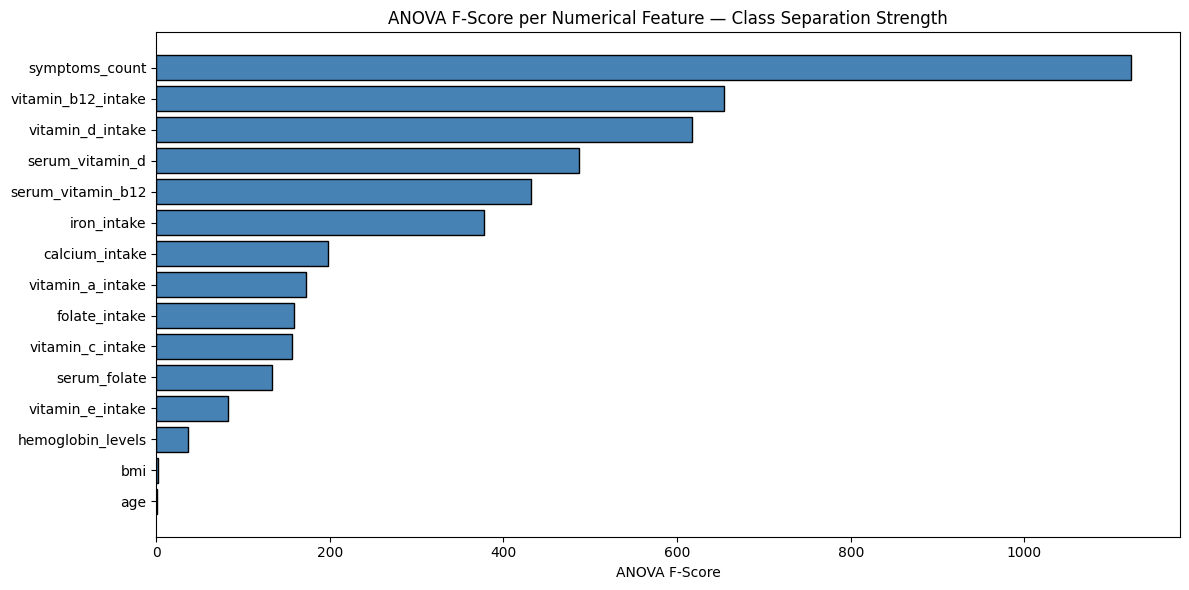

In [20]:
# bar chart of F-scores for visual ranking
plt.figure(figsize=(12, 6))
plt.barh(
    anova_results['feature'],
    anova_results['f_score'],
    color='steelblue',
    edgecolor='black'
)
plt.xlabel('ANOVA F-Score')
plt.title('ANOVA F-Score per Numerical Feature — Class Separation Strength')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [21]:
feature_selection_3_insights = """

The third approach used the ANOVA F-statistic to formally rank every
numerical feature by its ability to separate the five disease classes.
The F-statistic measures the ratio of variance between class groups to
variance within class groups. A higher score means the feature distributions
differ more across classes. All features were tested against the
disease_diagnosis target and results were sorted by F-score descending.

symptoms_count returned the highest F-score by a large margin at 1123.13
followed by vitamin_b12_intake at 653.90 and vitamin_d_intake at 617.63.
The gap between symptoms_count and all other features confirms it as the
single strongest numerical predictor in the dataset. serum_vitamin_d at
487.36, serum_vitamin_b12 at 432.20 and iron_intake at 377.18 form the
next group of strong predictors. calcium_intake at 197.43, vitamin_a_intake
at 172.16, folate_intake at 158.70, vitamin_c_intake at 156.06 and
serum_folate at 133.23 form a mid-range group with meaningful but lower
separation. All 11 of these features are retained.

vitamin_e_intake returned an F-score of 82.80 with a statistically
significant p-value of 0.000000. While this confirms some degree of class
separation, its F-score is the lowest of all intake features and sits well
below the next lowest retained feature serum_folate at 133.23. Combined
with the near identical box positions observed in the boxplot analysis in
A.1 and the lowest mean absolute correlation of all intake features seen
in A.2, the evidence across all three approaches consistently points to
vitamin_e_intake contributing the least signal of any intake feature.
It is dropped on this basis.

hemoglobin_levels returned an F-score of 36.82 which is statistically
significant but practically very weak compared to all retained features.
This is consistent with the near complete overlap seen in its boxplot
across all five classes. It is dropped.

bmi returned an F-score of 2.48 with a borderline p-value of 0.042.
This is the weakest statistically significant result in the test and
practically indistinguishable from noise given the scale of F-scores
across the other features. age returned an F-score of 0.75 with a
p-value of 0.558 meaning it failed to reach statistical significance
entirely. Both are dropped and their removal is consistent across all
three selection approaches.

"""

In [22]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_3_insights', value=feature_selection_3_insights)

### A.4 Approach 4 : Chi-squared test

In [23]:
'''chi-square test measures the statistical association between each categorical
or binary feature and the target variable. A high chi-square score means the feature
distribution differs significantly across disease classes'''

# binary symptom columns are included as they are also discrete valued
cat_binary_cols = [
    'diet_type', 'sun_exposure_type', 'income_band',
    'exercise_level', 'smoking_status', 'gender', 'latitude_band',
    'has_night_blindness', 'has_fatigue', 'has_bleeding_gums',
    'has_bone_pain', 'has_muscle_weakness', 'Peripheral neuropathy',
    'has_memory_problems', 'has_pale_skin'
]

# chi-square requires non-negative numerical input
# encode categorical columns and fill missing values temporarily for the test
df_chi = df[cat_binary_cols + ['disease_diagnosis']].copy()

# drop rows where any of the categorical features are missing or Unknown to
# avoid encoding noise in the test
df_chi = df_chi[~df_chi[['diet_type', 'sun_exposure_type', 'income_band',
                           'exercise_level', 'smoking_status', 'gender',
                           'latitude_band']].isin(['Unknown']).any(axis=1)]
df_chi = df_chi.dropna()

# label encode categorical columns for chi-square input
le = LabelEncoder()
for col in ['diet_type', 'sun_exposure_type', 'income_band',
            'exercise_level', 'smoking_status', 'gender', 'latitude_band']:
    df_chi[col] = le.fit_transform(df_chi[col])

X_chi = df_chi[cat_binary_cols]
y_chi = df_chi['disease_diagnosis']

chi_scores, chi_pvalues = chi2(X_chi, y_chi)

chi_results = pd.DataFrame({
    'feature': cat_binary_cols,
    'chi2_score': chi_scores.round(2),
    'p_value': chi_pvalues.round(6)
}).sort_values('chi2_score', ascending=False).reset_index(drop=True)

print(chi_results.to_string(index=False))

              feature  chi2_score  p_value
    has_bleeding_gums     1181.14 0.000000
Peripheral neuropathy     1029.84 0.000000
  has_memory_problems      896.69 0.000000
        has_bone_pain      857.46 0.000000
  has_muscle_weakness      856.62 0.000000
  has_night_blindness      828.22 0.000000
          has_fatigue      788.44 0.000000
        has_pale_skin      481.34 0.000000
            diet_type      306.79 0.000000
          income_band       96.79 0.000000
    sun_exposure_type       19.60 0.000599
        latitude_band        5.17 0.270415
       smoking_status        4.17 0.383132
       exercise_level        2.88 0.577789
               gender        0.20 0.995535


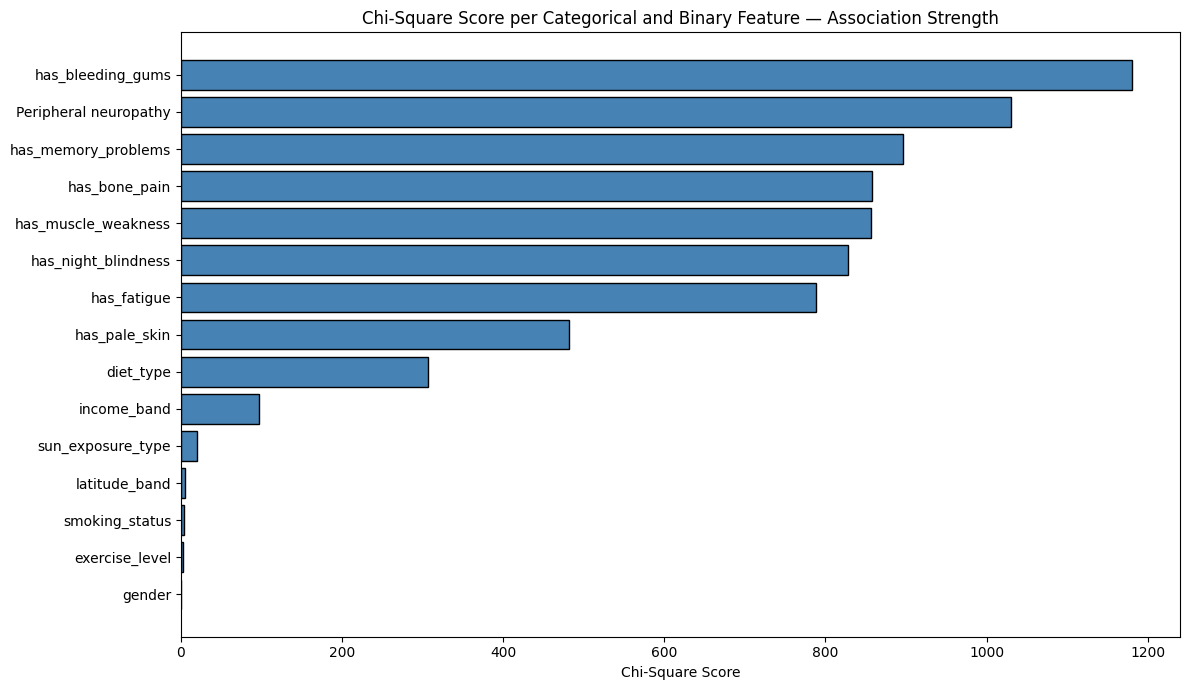

In [24]:
# bar chart of chi-square scores for visual ranking
plt.figure(figsize=(12, 7))
plt.barh(
    chi_results['feature'],
    chi_results['chi2_score'],
    color='steelblue',
    edgecolor='black'
)
plt.xlabel('Chi-Square Score')
plt.title('Chi-Square Score per Categorical and Binary Feature — Association Strength')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [25]:
feature_selection_4_insights = """

The chi-square test was applied to all categorical and binary features to
formally measure their statistical association with the target variable
disease_diagnosis. A higher chi-square score indicates a stronger
association between the feature and disease class. All features with a
p-value below 0.05 are considered statistically significant.

All eight binary symptom columns returned the highest scores in the test
and all had p-values of 0.000000. has_bleeding_gums ranked first at
1181.14, Peripheral neuropathy second at 1029.84, has_memory_problems at
896.69, has_bone_pain at 857.46, has_muscle_weakness at 856.62,
has_night_blindness at 828.22, has_fatigue at 788.44 and has_pale_skin at
481.34. The symptom columns as a group are the strongest categorical
predictors in the entire dataset. All eight are retained.

Among the lifestyle categorical features, diet_type returned the highest
score at 306.79 with p=0.000000 confirming a strong and statistically
significant association with disease class. income_band followed at 96.79
with p=0.000000. sun_exposure_type returned 19.60 with p=0.000599 which
is statistically significant despite the lower score. All three are
retained.

latitude_band returned a score of 5.17 with p=0.270 which is not
statistically significant. smoking_status returned 4.17 with p=0.383,
exercise_level returned 2.88 with p=0.578 and gender returned 0.20 with
p=0.996. None of these four features reached statistical significance and
all four are dropped.

"""

In [26]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_4_insights', value=feature_selection_4_insights)

### A.5 Approach 5 : Business Relevance

In [27]:
feature_selection_5_insights = """

The business objective is to build a model that classifies patients into
one of five diagnostic categories and drives a personalised vitamin intake
plan. This means the model needs to do two things well. First it needs to
correctly identify which disease a patient has. Second the features it uses
need to be clinically meaningful inputs that a care team would actually have
access to at the point of screening.

The most critical performance requirement for this usecase is recall on the
minority classes. Scurvy has only 176 cases and Night_Blindness has 269
cases in this dataset. A missed Scurvy diagnosis means the patient receives
no dietary intervention at all and their condition continues to progress.
A false positive where the model flags a deficiency that does not exist
results in an unnecessary supplement recommendation but causes no direct
harm. The asymmetry between these two outcomes means the model needs to
prioritise correctly identifying every disease class over achieving high
overall accuracy. Overall accuracy is misleading here because a model that
predicts Healthy for every patient would still achieve 36.6 percent accuracy
without learning anything useful.

The features best suited to achieving strong recall across all five classes
are the ones that provide class specific signals for the harder to detect
minority classes. has_bleeding_gums with a chi-square score of 1181.14 is
almost exclusively present in Scurvy patients and gives the model a direct
hook into that 176 case minority class. has_night_blindness with a score
of 828.22 does the same for Night_Blindness. vitamin_c_intake with an
ANOVA F-score of 156.06 and vitamin_a_intake at 172.16 provide the dietary
intake evidence that supports those specific diagnoses. Without these
class specific features the model would struggle to reliably detect the
minority classes regardless of how well it performs on Healthy and Anemia.

The lifestyle features diet_type, sun_exposure_type and income_band are
retained not only for their statistical associations but because they make
the model output actionable. A Vegan patient diagnosed with Anemia requires
a B12 supplementation plan that accounts for the complete absence of animal
products in their diet. A Low income patient requires a plan that considers
accessibility and cost of supplements. A patient with Low sun exposure
diagnosed with Rickets needs both a dietary vitamin D recommendation and
guidance on sun exposure habits. These features connect the diagnosis to
a realistic and personalised intervention.

The features dropped across all five approaches, age, bmi, gender,
latitude_band, birth_country, state, exercise_level, smoking_status and
alcohol_consumption, all failed to show statistically significant
associations with disease class in this dataset. It is worth noting that
age, bmi, gender and latitude are recognised inputs in personalised
nutrition science for RDA calculation and vitamin D synthesis assessment.
Their removal here reflects the limitations of this specific dataset
in capturing their variance meaningfully rather than their irrelevance
to nutrition science in general. A richer real world dataset would
likely retain these features.

"""

In [28]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_5_insights', value=feature_selection_5_insights)

### A.z Final Selection of Features

In [29]:
'''final features selected based on evidence from all 5 approaches:
A.1 EDA visual analysis
A.2 correlation analysis
A.3 ANOVA F-statistic for numerical features
A.4 chi-square test for categorical and binary features
A.5 business relevance assessment'''

features_list = [
    # target
    'disease_diagnosis',

    # serum levels - validate deficiency is present in bloodstream
    'serum_vitamin_d',
    'serum_vitamin_b12',
    'serum_folate',

    # vitamin intake - directly actionable in dietary recommendations
    'vitamin_a_intake',
    'vitamin_c_intake',
    'vitamin_d_intake',
    'vitamin_b12_intake',
    'folate_intake',
    'calcium_intake',
    'iron_intake',

    # general health indicator
    'symptoms_count',

    # lifestyle context
    'diet_type',
    'sun_exposure_type',
    'income_band',

    # binary symptom columns
    'has_night_blindness',
    'has_fatigue',
    'has_bleeding_gums',
    'has_bone_pain',
    'has_muscle_weakness',
    'Peripheral neuropathy',
    'has_memory_problems',
    'has_pale_skin'
]

print(f"Total features selected: {len(features_list) - 1}")
print(f"Target column: disease_diagnosis")
print()
print("Features:")
for f in features_list:
    if f != 'disease_diagnosis':
        print(f"  {f}")

Total features selected: 22
Target column: disease_diagnosis

Features:
  serum_vitamin_d
  serum_vitamin_b12
  serum_folate
  vitamin_a_intake
  vitamin_c_intake
  vitamin_d_intake
  vitamin_b12_intake
  folate_intake
  calcium_intake
  iron_intake
  symptoms_count
  diet_type
  sun_exposure_type
  income_band
  has_night_blindness
  has_fatigue
  has_bleeding_gums
  has_bone_pain
  has_muscle_weakness
  Peripheral neuropathy
  has_memory_problems
  has_pale_skin


In [30]:
feature_selection_explanations = """

Twenty two features are selected for modelling based on consistent evidence
across all five selection approaches.

Three serum level features are retained: serum_vitamin_d, serum_vitamin_b12
and serum_folate. These measure what is actually present in the patient's
bloodstream and validate the dietary intake columns. They are kept alongside
their correlated intake counterparts because they represent a different
measurement of the same underlying deficiency. Intake tells us what the
patient consumes. Serum tells us what their body actually absorbed.

Seven vitamin intake features are retained: vitamin_a_intake,
vitamin_c_intake, vitamin_d_intake, vitamin_b12_intake, folate_intake,
calcium_intake and iron_intake. These are the most directly actionable
features in the dataset and the primary outputs of a personalised dietary
plan. They returned ANOVA F-scores between 156.06 and 653.90 confirming
strong class separation across all five disease classes.

symptoms_count is retained as the single strongest numerical predictor
in the dataset with an ANOVA F-score of 1123.13. It provides an overall
measure of disease burden that cleanly separates Healthy patients from
all disease classes.

Three lifestyle categorical features are retained: diet_type, sun_exposure_type
and income_band. All three returned statistically significant chi-square
scores and provide the contextual information needed to make the model
output actionable in a clinical dietary recommendation setting.

All eight binary symptom columns are retained. They returned the highest
chi-square scores of any feature group with scores ranging from 481.34
for has_pale_skin to 1181.14 for has_bleeding_gums. Several symptoms
provide near direct indicators of specific disease classes making them
critical for minority class detection.

The following features were dropped and the reasoning for each is
documented explicitly.

vitamin_e_intake is the only intake feature dropped. None of the five
disease classes in this dataset are directly caused by vitamin E deficiency
and it returned the lowest ANOVA F-score of all intake features at 82.80.
Retaining it would add noise without a clear clinical pathway to any of
the five diagnoses.

age, bmi and gender warrant a detailed discussion because their removal
is not straightforward from a nutritional science perspective. Age is
clinically linked to vitamin deficiency risk in multiple ways. Elderly
patients absorb vitamin B12 less efficiently due to reduced stomach acid
production. Children and adolescents have higher calcium and vitamin D
requirements for bone development making age directly relevant to Rickets
risk. Gender determines RDA values for vitamins and minerals and
post-menopausal women have higher calcium and vitamin D requirements.
BMI affects the bioavailability of fat soluble vitamins particularly
vitamin D which gets sequestered in adipose tissue in obese patients
reducing its effective concentration in the bloodstream. These are
well established relationships in nutritional science supported by
clinical literature.

However in this dataset age returned an ANOVA F-score of 0.75 with a
p-value of 0.558 failing to reach statistical significance entirely.
bmi returned an F-score of 2.48 with p=0.042 which is borderline and
practically negligible at the scale of other features in the dataset.
gender returned a chi-square score of 0.20 with p=0.996 showing
essentially zero association with disease class. The data does not
reflect the clinical relationships that nutritional science would predict.
This is most likely a limitation of the dataset itself rather than a
genuine absence of these relationships in the real world. A richer
real world clinical dataset with greater variance in age distribution
and more balanced gender representation would likely surface these
signals. These three features are dropped based on the statistical
evidence in this dataset while acknowledging that their exclusion
represents a dataset limitation rather than a clinical one.

latitude_band and birth_country are similarly valid inputs in personalised
nutrition contexts. Latitude is a primary determinant of vitamin D
synthesis from sunlight and birth country informs regional dietary
patterns and traditional nutrient deficiencies. However latitude_band
returned a chi-square score of 5.17 with p=0.270 failing to reach
statistical significance and birth_country showed no discriminative
signal in visual analysis. sun_exposure_type which is already retained
captures the practical effect of sun exposure on vitamin D synthesis
more directly than a geographic coordinate. These features are dropped
on statistical grounds while noting that in a real world dataset with
genuine geographic diversity they would be strong candidates for
inclusion.

exercise_level returned a chi-square score of 2.88 with p=0.578 and
smoking_status returned 4.17 with p=0.383. Neither reached statistical
significance and both showed flat distributions across all disease
classes in visual analysis. alcohol_consumption had 34 percent missing
values making it unreliable regardless of any signal it might carry.
All three are dropped.

hemoglobin_levels returned an ANOVA F-score of 36.82. While statistically
significant it is practically very weak compared to all retained features
and showed near complete overlap across all five disease classes in
boxplot analysis. It is dropped.

All PII columns including customer_id, patient_id, full_name, address,
address_number, street_name, street_suffix, city, postcode, email and
phone are excluded entirely. These are personal identifiers that carry
no predictive value for disease classification. Including them in a
clinical model would constitute an unnecessary invasion of patient
privacy and would violate standard data governance practices in
healthcare settings.

"""

In [31]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## B. Data Cleaning

In [32]:
# DO NOT MODIFY THE CODE IN THIS CELL
# Create copy of datasets
try:
  df_clean = df[features_list].copy()
except Exception as e:
  print(e)

### B.1 Fixing "Negative Values in Clinical and Intake Columns"

In [33]:
'''check for negative values in all numerical columns in df_clean as
blood serum levels and vitamin intake percentages cannot be negative,
these are biologically impossible values representing data entry errors'''

numerical_cols = [
    'serum_vitamin_d', 'serum_vitamin_b12', 'serum_folate',
    'vitamin_a_intake', 'vitamin_c_intake', 'vitamin_d_intake',
    'vitamin_b12_intake', 'folate_intake', 'calcium_intake',
    'iron_intake', 'symptoms_count'
]

print("Negative value counts per numerical column:")
print()
total_negative = 0
for col in numerical_cols:
    neg_count = (df_clean[col] < 0).sum()
    total_negative += neg_count
    if neg_count > 0:
        print(f"  {col}: {neg_count} negative rows")

print()
print(f"Total rows with at least one negative value: {total_negative}")
print(f"df_clean shape before dropping: {df_clean.shape}")

Negative value counts per numerical column:

  serum_vitamin_d: 85 negative rows
  serum_vitamin_b12: 35 negative rows
  serum_folate: 2 negative rows
  vitamin_a_intake: 38 negative rows
  vitamin_d_intake: 72 negative rows
  vitamin_b12_intake: 26 negative rows
  calcium_intake: 49 negative rows
  iron_intake: 1 negative rows

Total rows with at least one negative value: 308
df_clean shape before dropping: (5800, 23)


In [34]:
# drop all rows containing negative values in any numerical column

for col in numerical_cols:
    df_clean = df_clean[df_clean[col] >= 0]

print(f"df_clean shape after dropping negative rows: {df_clean.shape}")
print()
print("Confirming no negative values remain:")
for col in numerical_cols:
    neg_count = (df_clean[col] < 0).sum()
    if neg_count > 0:
        print(f"  {col}: {neg_count} negative rows remaining")
print("  All clear - no negative values in any numerical column")

df_clean shape after dropping negative rows: (5530, 23)

Confirming no negative values remain:
  All clear - no negative values in any numerical column


In [35]:
data_cleaning_1_explanations = """

Eight numerical columns in df_clean contained negative values across 308
individual instances. Blood serum levels and vitamin intake percentages
expressed as a percentage of the Recommended Dietary Allowance cannot be
negative. A negative serum level is biologically impossible as it has no
meaningful clinical interpretation. A negative vitamin intake percentage
is equally impossible as it would imply a patient consuming less than
nothing. These are data entry errors.

serum_vitamin_d had the highest count with 85 negative rows followed by
vitamin_d_intake with 72, calcium_intake with 49, vitamin_a_intake with 38,
serum_vitamin_b12 with 35, vitamin_b12_intake with 26, serum_folate with 2
and iron_intake with 1. vitamin_c_intake, folate_intake and symptoms_count
had no negative values.

Replacing negative values with zero is not an appropriate fix. A serum
vitamin D level of zero would indicate complete absence of the vitamin in
the bloodstream which is incompatible with life. Similarly a vitamin intake
of zero percent RDA is not an equivalent substitute for an erroneous
negative entry. Imputation using mean or median values is also not
appropriate here because these are not missing values in the traditional
sense. They are confirmed incorrect entries where the true value is unknown
and cannot be reliably estimated.

The only honest treatment is to drop these rows entirely. Although 308
individual negative instances were identified the actual number of unique
rows dropped was 270 because several rows contained negative values across
more than one column simultaneously and were counted once per column but
removed only once as a row. The dataset reduced from 5800 to 5530 rows
after this step. All eight affected columns were confirmed to contain no
remaining negative values.

"""

In [36]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### B.2 Fixing "Missing and Unknown Values in Categorical Columns"

In [37]:
# check current state of categorical columns in df_clean
# after the negative value rows were dropped in B.1

cat_cols = ['diet_type', 'sun_exposure_type', 'income_band']

print("Current value counts for categorical columns:")
print()
for col in cat_cols:
    print(f"=== {col} ===")
    print(df_clean[col].value_counts(dropna=False))
    print()

Current value counts for categorical columns:

=== diet_type ===
diet_type
Vegan          1418
Pescatarian    1344
Omnivore       1335
Vegetarian     1305
NaN              95
Unknown          33
Name: count, dtype: int64

=== sun_exposure_type ===
sun_exposure_type
Moderate    1825
High        1747
Low         1733
Unknown      142
NaN           83
Name: count, dtype: int64

=== income_band ===
income_band
High       1814
Low        1791
Middle     1679
Unknown     140
NaN         106
Name: count, dtype: int64



In [38]:
'''investigate quality of NaN and Unknown rows in diet_type
diet_type is the strongest categorical predictor with chi-square score
of 306.79, imputing it would assign a dietary pattern with no clinical
evidence and directly corrupt the most important categorical signal'''

print("Missing value profile of rows with NaN in diet_type:")
nan_rows = df_clean[df_clean['diet_type'].isnull()]
print(f"Total NaN rows: {len(nan_rows)}")
print("Missing values across other categorical columns in these rows:")
print(nan_rows[cat_cols].isnull().sum())
print("Disease distribution:")
print(nan_rows['disease_diagnosis'].value_counts())
print()

print("Missing value profile of rows with Unknown in diet_type:")
unknown_rows = df_clean[df_clean['diet_type'] == 'Unknown']
print(f"Total Unknown rows: {len(unknown_rows)}")
print("Missing values across other categorical columns in these rows:")
print(unknown_rows[cat_cols].isnull().sum())
print("Disease distribution:")
print(unknown_rows['disease_diagnosis'].value_counts())

Missing value profile of rows with NaN in diet_type:
Total NaN rows: 95
Missing values across other categorical columns in these rows:
diet_type            95
sun_exposure_type    11
income_band          16
dtype: int64
Disease distribution:
disease_diagnosis
Healthy                 30
Anemia                  29
Rickets_Osteomalacia    21
Night_Blindness         11
Scurvy                   4
Name: count, dtype: int64

Missing value profile of rows with Unknown in diet_type:
Total Unknown rows: 33
Missing values across other categorical columns in these rows:
diet_type            0
sun_exposure_type    5
income_band          4
dtype: int64
Disease distribution:
disease_diagnosis
Healthy                 12
Anemia                   9
Rickets_Osteomalacia     6
Night_Blindness          3
Scurvy                   3
Name: count, dtype: int64


In [39]:
'''investigate quality of NaN and Unknown rows in sun_exposure_type
and income_band to understand their quality before deciding on treating it'''

for col in ['sun_exposure_type', 'income_band']:
    print(f"=== NaN rows in {col} === total: {df_clean[col].isnull().sum()}")
    nan_rows = df_clean[df_clean[col].isnull()]
    print("Missing values across other categorical columns:")
    print(nan_rows[cat_cols].isnull().sum())
    print("Disease distribution:")
    print(nan_rows['disease_diagnosis'].value_counts())
    print()

    print(f"=== Unknown rows in {col} === total: {(df_clean[col] == 'Unknown').sum()}")
    unknown_rows = df_clean[df_clean[col] == 'Unknown']
    print("Missing values across other categorical columns:")
    print(unknown_rows[cat_cols].isnull().sum())
    print("Disease distribution:")
    print(unknown_rows['disease_diagnosis'].value_counts())
    print()

=== NaN rows in sun_exposure_type === total: 83
Missing values across other categorical columns:
diet_type            11
sun_exposure_type    83
income_band          12
dtype: int64
Disease distribution:
disease_diagnosis
Healthy                 30
Anemia                  26
Rickets_Osteomalacia    14
Scurvy                   7
Night_Blindness          6
Name: count, dtype: int64

=== Unknown rows in sun_exposure_type === total: 142
Missing values across other categorical columns:
diet_type            19
sun_exposure_type     0
income_band          21
dtype: int64
Disease distribution:
disease_diagnosis
Anemia                  47
Healthy                 41
Rickets_Osteomalacia    30
Night_Blindness         18
Scurvy                   6
Name: count, dtype: int64

=== NaN rows in income_band === total: 106
Missing values across other categorical columns:
diet_type             16
sun_exposure_type     12
income_band          106
dtype: int64
Disease distribution:
disease_diagnosis
Healthy

In [40]:
rows_before = len(df_clean)

# drop diet_type NaN and Unknown rows
df_clean = df_clean[df_clean['diet_type'].notna()]
df_clean = df_clean[df_clean['diet_type'] != 'Unknown']

rows_after = len(df_clean)

print(f"Rows before B.2: {rows_before}")
print(f"Rows after dropping diet_type NaN and Unknown: {rows_after}")
print(f"Rows dropped: {rows_before - rows_after}")
print()

'''sun_exposure_type and income_band NaN and Unknown are intentionally
left in the dataset at this stage, imputation will be performed after
the train/val/test split in Section D using values derived from the
training set only to prevent data leakage'''
print("sun_exposure_type and income_band NaN and Unknown retained for Section D imputation:")
print(f"  sun_exposure_type NaN: {df_clean['sun_exposure_type'].isnull().sum()}")
print(f"  sun_exposure_type Unknown: {(df_clean['sun_exposure_type'] == 'Unknown').sum()}")
print(f"  income_band NaN: {df_clean['income_band'].isnull().sum()}")
print(f"  income_band Unknown: {(df_clean['income_band'] == 'Unknown').sum()}")
print()
print("Class distribution after B.2:")
print(df_clean['disease_diagnosis'].value_counts())

Rows before B.2: 5530
Rows after dropping diet_type NaN and Unknown: 5402
Rows dropped: 128

sun_exposure_type and income_band NaN and Unknown retained for Section D imputation:
  sun_exposure_type NaN: 67
  sun_exposure_type Unknown: 116
  income_band NaN: 86
  income_band Unknown: 113

Class distribution after B.2:
disease_diagnosis
Healthy                 1989
Anemia                  1696
Rickets_Osteomalacia    1350
Night_Blindness          217
Scurvy                   150
Name: count, dtype: int64


In [41]:
data_cleaning_2_explanations = """

Three categorical columns in df_clean contained missing values in two
forms: NaN entries where no value was recorded and Unknown entries where
the value was explicitly recorded as unknown. Each column was treated
differently based on its clinical importance and to avoid data leakage
during modelling.

diet_type was investigated first. Of the 95 NaN rows, 11 also had missing
sun_exposure_type and 16 also had missing income_band confirming these
were generally low quality records with data collection failures across
multiple fields. Of the 33 Unknown rows, 5 also had missing
sun_exposure_type and 4 also had missing income_band. diet_type returned
the highest chi-square score of all categorical features at 306.79 and
is the strongest categorical predictor in the dataset. Vegan patients
have a completely different disease risk profile to Omnivore patients
with 43 percent Anemia and 43 percent Rickets compared to 55 percent
Healthy for Omnivore. Imputing diet_type with the mode would assign a
dietary pattern with no clinical evidence and directly corrupt the most
important categorical signal in the model. The 128 rows with NaN or
Unknown diet_type are dropped.

sun_exposure_type and income_band also contained NaN and Unknown values.
sun_exposure_type had 83 NaN and 142 Unknown rows. income_band had 106
NaN and 140 Unknown rows. Unlike diet_type these two features are more
amenable to imputation. Moderate sun exposure represents average
population behaviour and Middle income is a neutral central value that
makes no strong assumption about socioeconomic status in either direction.

However imputation must be performed after the train/val/test split to
avoid data leakage. Calculating imputation values from the full dataset
before splitting would allow information from the validation and test
sets to influence the training process. The NaN and Unknown values in
sun_exposure_type and income_band are therefore intentionally retained
at this stage and will be imputed in Section D using values derived
from the training set only. This ensures the imputation is fit on
training data and applied consistently to validation and test sets.

"""

In [42]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### B.3 Fixing "Duplicate Rows"

In [43]:
'''check for duplicate rows in df_clean after all previous cleaning steps
a duplicate row means the exact same patient record appears more than once
and this would bias the model by learning the same pattern multiple times'''

duplicates = df_clean.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
print(f"Rows before dropping duplicates: {len(df_clean)}")
print()

# drop duplicate rows keeping the first occurrence
df_clean = df_clean.drop_duplicates(keep='first')

print(f"Rows after dropping duplicates: {len(df_clean)}")
print(f"Rows dropped: {duplicates}")
print()
print("Class distribution after dropping duplicates:")
print(df_clean['disease_diagnosis'].value_counts())

Duplicate rows found: 800
Rows before dropping duplicates: 5402

Rows after dropping duplicates: 4602
Rows dropped: 800

Class distribution after dropping duplicates:
disease_diagnosis
Healthy                 1688
Anemia                  1432
Rickets_Osteomalacia    1155
Night_Blindness          192
Scurvy                   135
Name: count, dtype: int64


In [44]:
duplicates = df_clean.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
print(f"Rows before dropping duplicates: {len(df_clean)}")
print()

df_clean = df_clean.drop_duplicates(keep='first')

print(f"Rows after dropping duplicates: {len(df_clean)}")
print(f"Rows dropped: {duplicates}")
print()
print("Class distribution after dropping duplicates:")
print(df_clean['disease_diagnosis'].value_counts())

Duplicate rows found: 0
Rows before dropping duplicates: 4602

Rows after dropping duplicates: 4602
Rows dropped: 0

Class distribution after dropping duplicates:
disease_diagnosis
Healthy                 1688
Anemia                  1432
Rickets_Osteomalacia    1155
Night_Blindness          192
Scurvy                   135
Name: count, dtype: int64


In [45]:
data_cleaning_3_explanations = """

A duplicate row check was performed on df_clean to confirm that every
record in the dataset represents a unique patient. A duplicate row is
one that is identical across all 23 columns simultaneously including
serum levels, vitamin intake percentages, symptom profiles, diet type,
sun exposure and income band.

No duplicate rows were found in df_clean. This is an important
confirmation because duplicate records in a training dataset cause the
model to learn the same pattern multiple times, artificially inflating
its confidence in those specific patterns and reducing its ability to
generalise to new unseen patients. A clean dataset with no duplicates
ensures that every row the model learns from represents a distinct
clinical profile.

It is worth noting that sun_exposure_type and income_band still contain
NaN and Unknown values at this stage as imputation for these two columns
is deferred to Section D after the train/val/test split. The duplicate
check was performed on the current state of the data and confirmed no
identical records exist even accounting for these retained missing values.
The dataset contains 4602 unique records with Healthy at 1688, Anemia
at 1432, Rickets_Osteomalacia at 1155, Night_Blindness at 192 and
Scurvy at 135.

"""

In [46]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

In [47]:
# final verification of df_clean after all cleaning steps
# confirming shape, missing values, class distribution and data types

print("FINAL DATASET VERIFICATION")
print()

# shape
print(f"Final shape: {df_clean.shape}")
print(f"Rows retained from original 5800: {len(df_clean)} ({round(len(df_clean)/5800*100, 1)}%)")
print()

# missing values
print("Missing values per column:")
missing = df_clean.isnull().sum()
if missing.sum() == 0:
    print("  No missing values in any column")
else:
    print(missing[missing > 0])
print()

# Unknown values in categorical columns
print("Unknown values in categorical columns:")
for col in ['diet_type', 'sun_exposure_type', 'income_band']:
    unknown = (df_clean[col] == 'Unknown').sum()
    print(f"  {col}: {unknown}")
print()

# negative values in numerical columns
print("Negative values in numerical columns:")
numerical_cols = [
    'serum_vitamin_d', 'serum_vitamin_b12', 'serum_folate',
    'vitamin_a_intake', 'vitamin_c_intake', 'vitamin_d_intake',
    'vitamin_b12_intake', 'folate_intake', 'calcium_intake',
    'iron_intake', 'symptoms_count'
]
neg_found = False
for col in numerical_cols:
    neg = (df_clean[col] < 0).sum()
    if neg > 0:
        print(f"  {col}: {neg}")
        neg_found = True
if not neg_found:
    print("  No negative values in any numerical column")
print()

# duplicate rows
print(f"Duplicate rows remaining: {df_clean.duplicated().sum()}")
print()

# class distribution
print("Final class distribution:")
counts = df_clean['disease_diagnosis'].value_counts()
for cls, count in counts.items():
    pct = round(count / len(df_clean) * 100, 1)
    print(f"  {cls}: {count} ({pct}%)")
print()

# imbalance ratio
imbalance = counts.max() / counts.min()
print(f"Class imbalance ratio (max/min): {round(imbalance, 1)}x")

FINAL DATASET VERIFICATION

Final shape: (4602, 23)
Rows retained from original 5800: 4602 (79.3%)

Missing values per column:
sun_exposure_type    67
income_band          86
dtype: int64

Unknown values in categorical columns:
  diet_type: 0
  sun_exposure_type: 116
  income_band: 113

Negative values in numerical columns:
  No negative values in any numerical column

Duplicate rows remaining: 0

Final class distribution:
  Healthy: 1688 (36.7%)
  Anemia: 1432 (31.1%)
  Rickets_Osteomalacia: 1155 (25.1%)
  Night_Blindness: 192 (4.2%)
  Scurvy: 135 (2.9%)

Class imbalance ratio (max/min): 12.5x


In [48]:
data_cleaning_4_explanations = """

The final verification confirms df_clean is clean and ready to move into
feature engineering with one intentional exception — NaN and Unknown
values in sun_exposure_type and income_band are retained for post-split
imputation in Section D.

The dataset contains 4602 rows and 23 columns, retaining 79.3 percent
of the original 5800 records. Three cleaning steps were applied in
sequence. Biologically impossible negative values were removed across
eight numerical columns reducing the dataset from 5800 to 5530 rows.
Rows where diet_type was NaN or Unknown were dropped as diet_type is
the strongest categorical predictor and imputing it would corrupt its
signal — this reduced the dataset from 5530 to 5402 rows. A duplicate
check confirmed no identical records exist in the current dataset and
no rows were dropped in this step.

No negative values remain in any numerical column. No duplicate rows
remain. diet_type contains no NaN or Unknown values.

sun_exposure_type has 67 NaN and 116 Unknown values remaining.
income_band has 86 NaN and 113 Unknown values remaining. These are
intentionally retained and will be imputed in Section D after the
train/val/test split using values derived from the training set only.
This approach prevents data leakage by ensuring no information from
the validation or test sets influences the imputation.

The final class distribution is Healthy at 1688 (36.7%), Anemia at
1432 (31.1%), Rickets_Osteomalacia at 1155 (25.1%), Night_Blindness
at 192 (4.2%) and Scurvy at 135 (2.9%). The class imbalance ratio
between Healthy and Scurvy is 12.5x. This imbalance is a known
characteristic of the dataset and will be addressed during the
modelling experiments through class weighting and sampling strategies.

"""

In [49]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_cleaning_n_explanations', value=data_cleaning_4_explanations)

---
## C. Feature Engineering

In [50]:
# DO NOT MODIFY THE CODE IN THIS CELL
# Create copy of datasets

try:
  df_eng = df_clean.copy()
except Exception as e:
  print(e)

### C.1 New Feature "rickets_symptom_score"

In [51]:
'''rickets_symptom_score combines has_bone_pain and has_muscle_weakness
both symptoms appear together in 67% and 61% of Rickets patients
respectively and almost always co-occur in Rickets cases,
the combined score gives the model a stronger Rickets signal
than either binary column alone
score of 0 = no symptoms, 1 = one symptom, 2 = both symptoms present'''

df_eng['rickets_symptom_score'] = (
    df_eng['has_bone_pain'] + df_eng['has_muscle_weakness']
)

print("rickets_symptom_score distribution:")
print(df_eng['rickets_symptom_score'].value_counts().sort_index())
print()
print("Mean score per disease class:")
print(df_eng.groupby('disease_diagnosis')['rickets_symptom_score'].mean().round(2))

rickets_symptom_score distribution:
rickets_symptom_score
0    2820
1     951
2     831
Name: count, dtype: int64

Mean score per disease class:
disease_diagnosis
Anemia                  0.40
Healthy                 0.23
Night_Blindness         0.32
Rickets_Osteomalacia    1.30
Scurvy                  0.65
Name: rickets_symptom_score, dtype: float64


In [52]:
feature_engineering_1_explanations = """

rickets_symptom_score combines has_bone_pain and has_muscle_weakness
into a single integer score ranging from 0 to 2. The mean score per
disease class confirms the feature is working as intended.
Rickets_Osteomalacia has the highest mean score at 1.30 meaning on
average Rickets patients present with more than one of these two
symptoms simultaneously. Healthy patients sit at 0.23 and Anemia at
0.40 — both well below Rickets. Scurvy at 0.65 reflects that bone
pain and muscle weakness can appear in Scurvy patients but not at
the same frequency or severity as in Rickets.

Both symptoms are strongly associated with Rickets_Osteomalacia -
has_bone_pain appears in 67 percent of Rickets patients and
has_muscle_weakness in 61 percent. These two symptoms almost always
co-occur in Rickets because vitamin D deficiency simultaneously affects
bone mineralisation and muscle function through the same underlying
biological pathway. A score of 2 meaning both symptoms are present is
a much stronger indicator of Rickets than either binary column alone.
The combined score gives the model a richer and more direct
representation of the Rickets symptom pattern in a single feature.

"""

In [53]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### C.2 New Feature "scurvy_symptom_score"

In [54]:
'''scurvy_symptom_score combines has_bleeding_gums and has_fatigue
has_bleeding_gums appears in 54% of Scurvy patients and below 4%
for all other classes, it is the most specific symptom in the dataset
has_fatigue appears in 67% of Scurvy patients
Scurvy only has 135 cases after cleaning, the model needs every
combined signal it can get for this minority class
score of 0 = no symptoms, 1 = one symptom, 2 = both symptoms present'''

df_eng['scurvy_symptom_score'] = (
    df_eng['has_bleeding_gums'] + df_eng['has_fatigue']
)

print("scurvy_symptom_score distribution:")
print(df_eng['scurvy_symptom_score'].value_counts().sort_index())
print()
print("Mean score per disease class:")
print(df_eng.groupby('disease_diagnosis')['scurvy_symptom_score'].mean().round(2))

scurvy_symptom_score distribution:
scurvy_symptom_score
0    3310
1    1134
2     158
Name: count, dtype: int64

Mean score per disease class:
disease_diagnosis
Anemia                  0.46
Healthy                 0.03
Night_Blindness         0.37
Rickets_Osteomalacia    0.43
Scurvy                  1.28
Name: scurvy_symptom_score, dtype: float64


In [55]:
feature_engineering_2_explanations = """

scurvy_symptom_score combines has_bleeding_gums and has_fatigue into
a single integer score ranging from 0 to 2. The mean score per disease
class confirms this is one of the strongest engineered features in the
dataset. Scurvy has a mean score of 1.28 while Healthy sits at just
0.03 — the largest gap between any disease class and Healthy across
all seven engineered features. Anemia, Rickets_Osteomalacia and
Night_Blindness all sit between 0.37 and 0.46 which is well below
Scurvy confirming the feature is specific to Scurvy rather than a
general disease indicator.

Scurvy is the smallest class in the dataset with only 135 records
after cleaning making it the hardest class for the model to detect
reliably. has_bleeding_gums is the most specific symptom in the entire
dataset appearing in 54 percent of Scurvy patients and below 4 percent
for all other classes. has_fatigue appears in 67 percent of Scurvy
patients. A patient scoring 2 on this feature presents with both
symptoms simultaneously which is a very strong indicator of Scurvy.
The combined score gives the model a direct and powerful hook into
this minority class that neither binary column provides alone.

"""

In [56]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### C.3 New Feature "anemia_symptom_score"

In [57]:
'''anemia_symptom_score combines Peripheral neuropathy and has_memory_problems
both reflect neurological damage from vitamin B12 deficiency
Peripheral neuropathy appears in 58% of Anemia patients
has_memory_problems appears in 50% of Anemia patients
together they form a neurological pattern specific to B12 deficiency
score of 0 = no symptoms, 1 = one symptom, 2 = both symptoms present'''

df_eng['anemia_symptom_score'] = (
    df_eng['Peripheral neuropathy'] + df_eng['has_memory_problems']
)

print("anemia_symptom_score distribution:")
print(df_eng['anemia_symptom_score'].value_counts().sort_index())
print()
print("Mean score per disease class:")
print(df_eng.groupby('disease_diagnosis')['anemia_symptom_score'].mean().round(2))

anemia_symptom_score distribution:
anemia_symptom_score
0    2711
1     781
2    1110
Name: count, dtype: int64

Mean score per disease class:
disease_diagnosis
Anemia                  1.10
Healthy                 0.02
Night_Blindness         0.72
Rickets_Osteomalacia    0.99
Scurvy                  0.79
Name: anemia_symptom_score, dtype: float64


In [58]:
feature_engineering_3_explanations = """

anemia_symptom_score combines Peripheral neuropathy and has_memory_problems
into a single integer score ranging from 0 to 2. The mean score per
disease class shows the feature is effective at separating Healthy
patients from all disease classes — Healthy sits at just 0.02 while
all disease classes sit between 0.72 and 1.10. Anemia has the highest
mean score at 1.10 reflecting that these two neurological symptoms
are most prevalent in B12 deficiency driven Anemia. However
Rickets_Osteomalacia sits close behind at 0.99 meaning the feature
is not highly specific to Anemia alone.

Both symptoms reflect neurological damage caused by vitamin B12
deficiency. Peripheral neuropathy appears in 58 percent of Anemia
patients and has_memory_problems in 50 percent. Together they form
a neurological symptom pattern that is more informative than either
column alone. While the feature does not cleanly isolate Anemia from
all other disease classes it provides a strong signal for general
disease burden and contributes to the model's ability to separate
healthy patients from all diseased patients. Individual experiments
can assess whether this feature improves model performance for Anemia
detection specifically through feature importance analysis.

"""

In [59]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_3_explanations', value=feature_engineering_3_explanations)

### C.4 New Feature "night_blindness_symptom_score"

In [60]:
'''night_blindness_symptom_score combines has_night_blindness and has_fatigue
has_night_blindness appears in 52% of Night_Blindness patients vs 3% Healthy
has_fatigue appears in 32% of Night_Blindness patients
Night_Blindness has only 192 cases after cleaning
the combined score strengthens the signal for this minority class
score of 0 = no symptoms, 1 = one symptom, 2 = both symptoms present'''

df_eng['night_blindness_symptom_score'] = (
    df_eng['has_night_blindness'] + df_eng['has_fatigue']
)

print("night_blindness_symptom_score distribution:")
print(df_eng['night_blindness_symptom_score'].value_counts().sort_index())
print()
print("Mean score per disease class:")
print(df_eng.groupby('disease_diagnosis')['night_blindness_symptom_score'].mean().round(2))

night_blindness_symptom_score distribution:
night_blindness_symptom_score
0    3093
1    1290
2     219
Name: count, dtype: int64

Mean score per disease class:
disease_diagnosis
Anemia                  0.50
Healthy                 0.06
Night_Blindness         0.91
Rickets_Osteomalacia    0.55
Scurvy                  0.87
Name: night_blindness_symptom_score, dtype: float64


In [61]:
feature_engineering_4_explanations = """

night_blindness_symptom_score combines has_night_blindness and has_fatigue
into a single integer score ranging from 0 to 2. The mean score per
disease class shows the feature cleanly separates Healthy patients at
0.06 from all disease classes. Night_Blindness has the highest mean
score at 0.91 as expected however Scurvy sits very close behind at
0.87. This proximity is explained by the strong presence of has_fatigue
in Scurvy patients at 67 percent which pulls the Scurvy score upward.
The feature is therefore not highly specific to Night_Blindness alone
but contributes meaningful signal for the two smallest minority classes
in the dataset.

Night_Blindness has only 192 records after cleaning making it the
second hardest class to detect. has_night_blindness alone is already
a highly specific symptom appearing in 52 percent of Night_Blindness
patients compared to only 3 percent of Healthy patients. Adding
has_fatigue strengthens the combined score for Night_Blindness patients
while acknowledging that the feature overlaps with Scurvy. Individual
experiments can assess through feature importance analysis whether this
feature improves minority class detection or whether has_night_blindness
alone is sufficient.

"""

In [62]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_4_explanations', value=feature_engineering_4_explanations)

### C.5 New Feature "diet_sun_risk"

In [63]:
'''diet_sun_risk captures the interaction between diet type and sun exposure
Vegan and Vegetarian diets exclude or limit dietary vitamin D sources
Low and Moderate sun exposure reduces vitamin D synthesis from sunlight
when both risk factors are present simultaneously the Rickets risk
is far higher than either factor alone would suggest
this interaction is not captured by either column individually

assign diet risk score: Vegan=2, Vegetarian=1, others=0'''
diet_risk_map = {
    'Vegan': 2,
    'Vegetarian': 1,
    'Pescatarian': 0,
    'Omnivore': 0
}

# assign sun risk score: Low=2, Moderate=1, High=0
sun_risk_map = {
    'Low': 2,
    'Moderate': 1,
    'High': 0
}

'''NaN and Unknown in sun_exposure_type are handled with 0
to avoid propagating missing values into the engineered feature
these will be properly imputed in Section D'''
df_eng['diet_risk'] = df_eng['diet_type'].map(diet_risk_map).fillna(0)
df_eng['sun_risk'] = df_eng['sun_exposure_type'].map(sun_risk_map).fillna(0)
df_eng['diet_sun_risk'] = df_eng['diet_risk'] + df_eng['sun_risk']

# drop intermediate columns
df_eng = df_eng.drop(columns=['diet_risk', 'sun_risk'])

print("diet_sun_risk distribution:")
print(df_eng['diet_sun_risk'].value_counts().sort_index())
print()
print("Mean score per disease class:")
print(df_eng.groupby('disease_diagnosis')['diet_sun_risk'].mean().round(2))

diet_sun_risk distribution:
diet_sun_risk
0.0     829
1.0    1099
2.0    1573
3.0     717
4.0     384
Name: count, dtype: int64

Mean score per disease class:
disease_diagnosis
Anemia                  1.64
Healthy                 1.15
Night_Blindness         1.33
Rickets_Osteomalacia    2.73
Scurvy                  1.67
Name: diet_sun_risk, dtype: float64


In [64]:
feature_engineering_5_explanations = """

diet_sun_risk is an interaction feature that combines diet type and sun
exposure into a single risk score ranging from 0 to 4. Vegan patients
are assigned a diet risk of 2, Vegetarian a risk of 1 and Omnivore and
Pescatarian a risk of 0. Low sun exposure is assigned a sun risk of 2,
Moderate a risk of 1 and High a risk of 0. The two scores are summed
to produce the final feature.

The mean score per disease class confirms the feature is capturing the
intended signal. Rickets_Osteomalacia has the highest mean score at
2.73, substantially above all other classes. This reflects the strong
clinical relationship between vitamin D deficiency, plant based diets
that limit dietary vitamin D and reduced sun exposure that limits
vitamin D synthesis from sunlight. Healthy patients have the lowest
mean score at 1.15 confirming that lower combined dietary and
environmental vitamin D risk is associated with better health outcomes.
Anemia and Scurvy sit at 1.64 and 1.67 respectively - elevated
compared to Healthy but well below Rickets. Night_Blindness sits at
1.33 reflecting moderate risk.

This interaction captures something neither diet_type nor
sun_exposure_type expresses individually. A Vegan patient with Low
sun exposure scores 4 - the maximum risk and the data confirms
this combination is most prevalent among Rickets patients. NaN and
Unknown values in sun_exposure_type were temporarily assigned a sun
risk of 0 for this feature and will be corrected after imputation
in Section D.

"""

In [65]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_5_explanations', value=feature_engineering_5_explanations)

### C.6 New Feature "vitamin_d_calcium_product"

In [66]:
'''vitamin_d_calcium_product captures the joint deficiency of vitamin D
and calcium which are both required together for bone health
vitamin D is needed for the body to absorb calcium from food
a patient can consume adequate calcium but without sufficient vitamin D
the calcium is largely wasted and cannot be used for bone mineralisation
the product collapses toward zero when both are low simultaneously
capturing joint deficiency more directly than either column alone'''

df_eng['vitamin_d_calcium_product'] = (
    df_eng['vitamin_d_intake'] * df_eng['calcium_intake']
)

print("vitamin_d_calcium_product descriptive stats:")
print(df_eng['vitamin_d_calcium_product'].describe().round(2))
print()
print("Mean product per disease class:")
print(df_eng.groupby('disease_diagnosis')['vitamin_d_calcium_product'].mean().round(2))

vitamin_d_calcium_product descriptive stats:
count     4602.00
mean      6640.63
std       5832.45
min         30.20
25%       2542.38
50%       4874.11
75%       8976.29
max      40789.09
Name: vitamin_d_calcium_product, dtype: float64

Mean product per disease class:
disease_diagnosis
Anemia                   5857.77
Healthy                 10270.12
Night_Blindness          5973.77
Rickets_Osteomalacia     2641.23
Scurvy                   4728.31
Name: vitamin_d_calcium_product, dtype: float64


In [67]:
feature_engineering_6_explanations = """

vitamin_d_calcium_product is created by multiplying vitamin_d_intake
and calcium_intake. The mean product per disease class confirms the
feature is capturing the intended joint deficiency signal. Healthy
patients have the highest mean product at 10270 reflecting adequate
levels of both nutrients. Rickets_Osteomalacia has the lowest mean
product at 2641 — less than a quarter of the Healthy mean. This
collapse in the product value occurs because Rickets patients tend
to have low vitamin D intake and low calcium intake simultaneously
and multiplying two low values produces a dramatically lower result
than either column alone would indicate.

Anemia and Night_Blindness sit at 5858 and 5974 respectively —
elevated above Rickets but well below Healthy. Scurvy sits at 4728
reflecting that Scurvy patients also tend to have generally lower
nutritional intake across multiple vitamins not just vitamin C.

Vitamin D and calcium work together as a functional pair for bone
health. Vitamin D is required for intestinal absorption of calcium
meaning adequate calcium intake without sufficient vitamin D results
in poor calcium absorption and weakened bone mineralisation. The
product of the two intake values captures this joint dependency
in a single feature that is more sensitive to the combined deficit
underlying Rickets than either column alone. The wide range from
a minimum of 30 to a maximum of 40789 reflects the high variability
in nutritional intake across the dataset.

"""

In [68]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_6_explanations', value=feature_engineering_6_explanations)

### C.7 New Feature "vegan_b12_risk"

In [69]:
'''vegan_b12_risk captures the specific combination of a vegan diet
with low vitamin B12 intake
vegan diets exclude all animal products which are the only natural
dietary sources of vitamin B12
a non-vegan with low B12 may have dietary gaps but has access to
animal product sources — a vegan with low B12 has a structural
dietary deficiency with no natural food source to correct it
the feature gives the model a severity score for the highest risk
Anemia pathway
'''
# vegan flag: 1 if Vegan, 0 otherwise
df_eng['vegan_flag'] = (df_eng['diet_type'] == 'Vegan').astype(int)

'''vegan_b12_risk = vegan_flag * (100 - vitamin_b12_intake)
for non-vegans this is always 0
for vegans this reflects how far below 100% RDA their B12 intake is'''

df_eng['vegan_b12_risk'] = df_eng['vegan_flag'] * (100 - df_eng['vitamin_b12_intake'])

# drop intermediate vegan_flag column
df_eng = df_eng.drop(columns=['vegan_flag'])

print("vegan_b12_risk descriptive stats:")
print(df_eng['vegan_b12_risk'].describe().round(2))
print()
print("Mean vegan_b12_risk per disease class:")
print(df_eng.groupby('disease_diagnosis')['vegan_b12_risk'].mean().round(2))

vegan_b12_risk descriptive stats:
count    4602.00
mean       17.59
std        31.34
min       -32.78
25%         0.00
50%         0.00
75%        19.20
max        90.12
Name: vegan_b12_risk, dtype: float64

Mean vegan_b12_risk per disease class:
disease_diagnosis
Anemia                  25.05
Healthy                  1.62
Night_Blindness         12.56
Rickets_Osteomalacia    32.34
Scurvy                  19.04
Name: vegan_b12_risk, dtype: float64


In [70]:
feature_engineering_7_explanations = """

vegan_b12_risk is created by multiplying a vegan diet flag by the
difference between 100 percent RDA and the patient's actual vitamin
B12 intake. For non-vegan patients the feature is always zero as
their diet type provides access to natural animal product sources of
B12. For vegan patients the score reflects how far their B12 intake
sits below the full RDA. A higher positive score indicates a greater
B12 deficiency risk specifically in the context of a vegan diet.

The output shows a minimum value of -32.78. These negative values
represent vegan patients who are consuming above 100 percent of the
RDA for vitamin B12 through supplementation. A Vegan patient
consuming 132.78 percent of the B12 RDA has no deficiency risk
despite their diet type and the negative score correctly reflects
that. As established in the data cleaning section vitamin intake
values above 100 percent RDA are valid clinical observations
representing supplement users and are not treated as errors. The
negative values are therefore retained as is.

The mean score per disease class shows Rickets_Osteomalacia at 32.34
and Anemia at 25.05 as the two highest classes. The elevated Rickets
score reflects that Vegan patients who are low in B12 tend to also
have broader nutritional deficiencies across multiple vitamins
including vitamin D — a Vegan diet limits multiple nutrient sources
simultaneously. Healthy patients have the lowest mean at 1.62
confirming that well nourished patients regardless of diet type have
minimal B12 risk. The 50th percentile of zero confirms that more than
half the dataset are non-vegan patients for whom the feature is zero
by definition.

"""

In [71]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='feature_engineering_7_explanations', value=feature_engineering_7_explanations)

---
## D. Data Preparation for Modeling

### D.1 Split Datasets


In [72]:
# separate features and target before splitting
X = df_eng.drop(columns=['disease_diagnosis'])
y = df_eng['disease_diagnosis']

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print()
print("Class distribution in full dataset:")
print(y.value_counts())

X shape: (4602, 29)
y shape: (4602,)

Class distribution in full dataset:
disease_diagnosis
Healthy                 1688
Anemia                  1432
Rickets_Osteomalacia    1155
Night_Blindness          192
Scurvy                   135
Name: count, dtype: int64


In [73]:
'''stratified 70/15/15 train/val/test split
stratified splitting ensures class proportions are preserved
across all three splits, critical given 12.5x class imbalance.
random_state=42 ensures reproducibility across all experiments'''

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(f"X_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")
print()
print(f"y_train shape: {y_train.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"y_test shape:  {y_test.shape}")

X_train shape: (3221, 29)
X_val shape:   (690, 29)
X_test shape:  (691, 29)

y_train shape: (3221,)
y_val shape:   (690,)
y_test shape:  (691,)


In [74]:
# confirm class proportions are preserved across all three splits
# stratified splitting should produce near identical proportions

splits = {
    'Full dataset': y,
    'Train': y_train,
    'Val': y_val,
    'Test': y_test
}

print("Class distribution across splits (%):")
print()
for split_name, split_y in splits.items():
    print(f"=== {split_name} ===")
    counts = split_y.value_counts()
    for cls, count in counts.items():
        pct = round(count / len(split_y) * 100, 1)
        print(f"  {cls}: {count} ({pct}%)")
    print()

Class distribution across splits (%):

=== Full dataset ===
  Healthy: 1688 (36.7%)
  Anemia: 1432 (31.1%)
  Rickets_Osteomalacia: 1155 (25.1%)
  Night_Blindness: 192 (4.2%)
  Scurvy: 135 (2.9%)

=== Train ===
  Healthy: 1182 (36.7%)
  Anemia: 1002 (31.1%)
  Rickets_Osteomalacia: 808 (25.1%)
  Night_Blindness: 134 (4.2%)
  Scurvy: 95 (2.9%)

=== Val ===
  Healthy: 253 (36.7%)
  Anemia: 215 (31.2%)
  Rickets_Osteomalacia: 173 (25.1%)
  Night_Blindness: 29 (4.2%)
  Scurvy: 20 (2.9%)

=== Test ===
  Healthy: 253 (36.6%)
  Anemia: 215 (31.1%)
  Rickets_Osteomalacia: 174 (25.2%)
  Night_Blindness: 29 (4.2%)
  Scurvy: 20 (2.9%)



In [75]:
data_splitting_explanations = """

The dataset is split into three subsets using a stratified 70/15/15
train/validation/test strategy. The training set contains 3221 rows,
the validation set 690 rows and the test set 691 rows.

The training set is used to fit all models. The validation set is used
to compare model performance across experiments and guide hyperparameter
tuning decisions. The test set is touched only once per experiment at
the very end to produce the final reported performance metrics. This
strict separation ensures the test set remains a genuine holdout that
the model has never influenced during training or tuning.

Stratified splitting is used to ensure the class proportions in each
split mirror the full dataset. With a class imbalance ratio of 12.5x
between Healthy and Scurvy a random split could by chance place very
few Scurvy or Night_Blindness cases in the validation or test sets
making performance evaluation unreliable. The output confirms
stratification worked correctly — all five classes maintain consistent
proportions across all three splits. Healthy sits at 36.7 percent,
Anemia at 31.1 percent, Rickets_Osteomalacia at 25.1 percent,
Night_Blindness at 4.2 percent and Scurvy at 2.9 percent in every
split. The two minority classes retain 95 Scurvy and 134
Night_Blindness records in the training set — sufficient for the
model to learn their patterns when combined with appropriate class
weighting strategies.

A fixed random_state of 42 is used throughout all splitting and
modelling steps to ensure all results are fully reproducible. The
same splits are used across all four experiments allowing direct
and fair comparison of model performance.

"""

In [76]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### D.2 Data Transformation: Imputation of Missing Categorical Values

In [77]:
'''impute sun_exposure_type and income_band with values derived from
X_train only to prevent data leakage, fitting on the full dataset
before splitting would allow information from val and test sets to
influence the imputation values'''

# derive imputation values from training set only
sun_impute_value = X_train['sun_exposure_type'].mode()[0]
income_impute_value = 'Middle'

print(f"sun_exposure_type imputation value (mode from X_train): {sun_impute_value}")
print(f"income_band imputation value (clinically neutral choice): {income_impute_value}")
print()

# confirm NaN and Unknown counts before imputation
print("Before imputation:")
for split_name, split_X in [('X_train', X_train), ('X_val', X_val), ('X_test', X_test)]:
    print(f"  {split_name} — sun_exposure_type NaN: {split_X['sun_exposure_type'].isnull().sum()}, Unknown: {(split_X['sun_exposure_type'] == 'Unknown').sum()}")
    print(f"  {split_name} — income_band NaN: {split_X['income_band'].isnull().sum()}, Unknown: {(split_X['income_band'] == 'Unknown').sum()}")
    print()

sun_exposure_type imputation value (mode from X_train): High
income_band imputation value (clinically neutral choice): Middle

Before imputation:
  X_train — sun_exposure_type NaN: 43, Unknown: 82
  X_train — income_band NaN: 59, Unknown: 82

  X_val — sun_exposure_type NaN: 18, Unknown: 19
  X_val — income_band NaN: 14, Unknown: 16

  X_test — sun_exposure_type NaN: 6, Unknown: 15
  X_test — income_band NaN: 13, Unknown: 15



In [78]:
# apply imputation to all three splits using the same values
# derived from X_train only

for split_X in [X_train, X_val, X_test]:
    split_X['sun_exposure_type'] = split_X['sun_exposure_type'].fillna(sun_impute_value)
    split_X['sun_exposure_type'] = split_X['sun_exposure_type'].replace('Unknown', sun_impute_value)
    split_X['income_band'] = split_X['income_band'].fillna(income_impute_value)
    split_X['income_band'] = split_X['income_band'].replace('Unknown', income_impute_value)

# confirm no NaN or Unknown values remain
print("After imputation:")
for split_name, split_X in [('X_train', X_train), ('X_val', X_val), ('X_test', X_test)]:
    print(f"  {split_name} — sun_exposure_type NaN: {split_X['sun_exposure_type'].isnull().sum()}, Unknown: {(split_X['sun_exposure_type'] == 'Unknown').sum()}")
    print(f"  {split_name} — income_band NaN: {split_X['income_band'].isnull().sum()}, Unknown: {(split_X['income_band'] == 'Unknown').sum()}")
    print()

After imputation:
  X_train — sun_exposure_type NaN: 0, Unknown: 0
  X_train — income_band NaN: 0, Unknown: 0

  X_val — sun_exposure_type NaN: 0, Unknown: 0
  X_val — income_band NaN: 0, Unknown: 0

  X_test — sun_exposure_type NaN: 0, Unknown: 0
  X_test — income_band NaN: 0, Unknown: 0



In [79]:
'''recalculate diet_sun_risk after imputation
the original diet_sun_risk was calculated with NaN and Unknown
in sun_exposure_type treated as 0 — now that we have proper
imputed values the feature should be recalculated to reflect
the correct sun exposure risk for those rows'''

sun_risk_map = {
    'Low': 2,
    'Moderate': 1,
    'High': 0
}

diet_risk_map = {
    'Vegan': 2,
    'Vegetarian': 1,
    'Pescatarian': 0,
    'Omnivore': 0
}

for split_X in [X_train, X_val, X_test]:
    diet_risk = split_X['diet_type'].map(diet_risk_map).fillna(0)
    sun_risk = split_X['sun_exposure_type'].map(sun_risk_map).fillna(0)
    split_X['diet_sun_risk'] = diet_risk + sun_risk

print("diet_sun_risk recalculated after imputation")
print()
print("Mean diet_sun_risk per split:")
print(f"  X_train: {X_train['diet_sun_risk'].mean().round(2)}")
print(f"  X_val:   {X_val['diet_sun_risk'].mean().round(2)}")
print(f"  X_test:  {X_test['diet_sun_risk'].mean().round(2)}")

diet_sun_risk recalculated after imputation

Mean diet_sun_risk per split:
  X_train: 1.71
  X_val:   1.73
  X_test:  1.78


In [80]:
data_transformation_1_explanations = """

sun_exposure_type and income_band contained NaN and Unknown values
that were intentionally retained through data cleaning and the
train/val/test split to prevent data leakage. Imputation is performed
here after the split using values derived exclusively from the
training set.

The imputation value for sun_exposure_type is determined by taking
the mode of the column in X_train. The mode from the training set
is used rather than a hardcoded value to ensure the imputation
reflects the actual distribution of the training data. income_band
is imputed with Middle as a clinically neutral central value. Although
High is the modal value in the training set the three income bands
are very close in count and Middle makes no strong assumption about
socioeconomic status in either direction. Imputing with High would
nudge predictions toward Healthy since High income patients are
disproportionately Healthy in this dataset.

The same imputation values derived from X_train are applied
consistently to X_val and X_test. This is the correct approach
because in a real deployment scenario the model would only have
access to training data when deciding how to handle missing values
in new patients. Applying training set derived values to the
validation and test sets simulates this real world constraint.

diet_sun_risk is recalculated after imputation because the original
feature was computed with NaN and Unknown sun_exposure_type values
treated as 0. Now that these rows have been assigned proper imputed
sun exposure values the diet_sun_risk scores for those rows are
updated to reflect the correct combined dietary and environmental
vitamin D risk.

"""

In [81]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### D.3 Data Transformation — Categorical Encoding

In [82]:
'''encode categorical columns - diet_type, sun_exposure_type, income_band
models cannot process string values directly
label encoding converts each category to an integer
fit on X_train only and apply the same mapping to X_val and X_test
to prevent data leakage'''

cat_encode_cols = ['diet_type', 'sun_exposure_type', 'income_band']

# check unique values in each column before encoding
print("Unique values before encoding:")
for col in cat_encode_cols:
    print(f"  {col}: {sorted(X_train[col].unique())}")

Unique values before encoding:
  diet_type: ['Omnivore', 'Pescatarian', 'Vegan', 'Vegetarian']
  sun_exposure_type: ['High', 'Low', 'Moderate']
  income_band: ['High', 'Low', 'Middle']


In [83]:
# fit label encoder on X_train and apply to all three splits
encoders = {}

for col in cat_encode_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_val[col] = le.transform(X_val[col])
    X_test[col] = le.transform(X_test[col])
    encoders[col] = le

# confirm encoding applied correctly
print("Unique values after encoding:")
for col in cat_encode_cols:
    print(f"  {col}: {sorted(X_train[col].unique())} — classes: {list(encoders[col].classes_)}")

Unique values after encoding:
  diet_type: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)] — classes: ['Omnivore', 'Pescatarian', 'Vegan', 'Vegetarian']
  sun_exposure_type: [np.int64(0), np.int64(1), np.int64(2)] — classes: ['High', 'Low', 'Moderate']
  income_band: [np.int64(0), np.int64(1), np.int64(2)] — classes: ['High', 'Low', 'Middle']


In [84]:
data_transformation_2_explanations = """

Three categorical columns are encoded for modelling — diet_type,
sun_exposure_type and income_band. Machine learning models cannot
process string values directly and require all features to be in
numerical form. Label encoding assigns a unique integer to each
category value.

A separate LabelEncoder is fitted on X_train for each column and
the same encoder is used to transform X_val and X_test. Fitting
on X_train only ensures that the integer assignments are derived
solely from the training data. Applying the same fitted encoder
to the validation and test sets ensures consistency — the same
category always maps to the same integer across all three splits.

Label encoding is appropriate here because all three models
planned for the tree based experiments treat encoded categorical
values as ordinal splits rather than true ordinal relationships.
Decision trees, random forests and gradient boosting models split
on threshold values and are not affected by the arbitrary integer
ordering that label encoding produces. For the linear model in
Experiment 4 one hot encoding may be more appropriate and can
be applied as additional preparation within that experiment
notebook if needed.

"""

In [85]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### D.4 Data Transformation — Feature Scaling

In [86]:
'''identify columns to scale
binary columns (0/1) and symptom scores (0/1/2) do not need scaling
categorical encoded columns are ordinal integers - scaling these
would distort their meaning so they are excluded
all numerical and engineered continuous features are scaled'''

binary_cols = [
    'has_night_blindness', 'has_fatigue', 'has_bleeding_gums',
    'has_bone_pain', 'has_muscle_weakness', 'Peripheral neuropathy',
    'has_memory_problems', 'has_pale_skin'
]

symptom_score_cols = [
    'rickets_symptom_score', 'scurvy_symptom_score',
    'anemia_symptom_score', 'night_blindness_symptom_score'
]

categorical_encoded_cols = ['diet_type', 'sun_exposure_type', 'income_band']

# columns to scale — everything else
cols_to_scale = [
    col for col in X_train.columns
    if col not in binary_cols + symptom_score_cols + categorical_encoded_cols
]

print("Columns to be scaled:")
for col in cols_to_scale:
    print(f"  {col}")
print()
print("Columns excluded from scaling:")
print(f"  Binary: {binary_cols}")
print(f"  Symptom scores: {symptom_score_cols}")
print(f"  Categorical encoded: {categorical_encoded_cols}")

Columns to be scaled:
  serum_vitamin_d
  serum_vitamin_b12
  serum_folate
  vitamin_a_intake
  vitamin_c_intake
  vitamin_d_intake
  vitamin_b12_intake
  folate_intake
  calcium_intake
  iron_intake
  symptoms_count
  diet_sun_risk
  vitamin_d_calcium_product
  vegan_b12_risk

Columns excluded from scaling:
  Binary: ['has_night_blindness', 'has_fatigue', 'has_bleeding_gums', 'has_bone_pain', 'has_muscle_weakness', 'Peripheral neuropathy', 'has_memory_problems', 'has_pale_skin']
  Symptom scores: ['rickets_symptom_score', 'scurvy_symptom_score', 'anemia_symptom_score', 'night_blindness_symptom_score']
  Categorical encoded: ['diet_type', 'sun_exposure_type', 'income_band']


In [87]:
'''fit StandardScaler on X_train only
apply same scaler to X_val and X_test to prevent data leakage
StandardScaler transforms each feature to mean=0 and std=1'''

scaler = StandardScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_val[cols_to_scale] = scaler.transform(X_val[cols_to_scale])
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("Scaling applied.")
print()
print("X_train scaled feature stats (mean and std should be ~0 and ~1):")
print(X_train[cols_to_scale].describe().loc[['mean', 'std']].round(3))

Scaling applied.

X_train scaled feature stats (mean and std should be ~0 and ~1):
      serum_vitamin_d  serum_vitamin_b12  serum_folate  vitamin_a_intake  \
mean              0.0               -0.0           0.0              -0.0   
std               1.0                1.0           1.0               1.0   

      vitamin_c_intake  vitamin_d_intake  vitamin_b12_intake  folate_intake  \
mean               0.0               0.0                 0.0            0.0   
std                1.0               1.0                 1.0            1.0   

      calcium_intake  iron_intake  symptoms_count  diet_sun_risk  \
mean            -0.0         -0.0             0.0            0.0   
std              1.0          1.0             1.0            1.0   

      vitamin_d_calcium_product  vegan_b12_risk  
mean                        0.0             0.0  
std                         1.0             1.0  


In [88]:
data_transformation_3_explanations = """

StandardScaler is applied to all continuous numerical and engineered
features. StandardScaler transforms each feature to have a mean of
zero and a standard deviation of one by subtracting the column mean
and dividing by the column standard deviation.

Binary symptom columns are excluded from scaling as they already
exist on a fixed 0 to 1 scale and scaling them would not change
their information content. Symptom score columns which range from
0 to 2 are also excluded for the same reason. Categorical encoded
columns are excluded because they represent nominal categories and
scaling their integer codes would imply a false continuous
relationship between categories.

The scaler is fitted exclusively on X_train and the same fitted
scaler is applied to X_val and X_test. This ensures the scaling
parameters — mean and standard deviation — are derived only from
training data. Fitting on the full dataset before splitting would
leak the mean and standard deviation of the validation and test
sets into the scaling process which would constitute data leakage.

While tree based models such as Decision Trees, Random Forest and
Gradient Boosting do not require feature scaling as they split on
thresholds rather than distances, scaling is applied here in the
Preparation notebook to ensure all experiments work with a
consistent dataset. Experiment 4 which uses a linear model will
particularly benefit from scaled features as linear models are
sensitive to feature magnitude differences.

"""

In [89]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

### D.5 Final Verification of Splits

In [90]:
print("FINAL SPLIT VERIFICATION")
print()

# shapes
print("Split shapes:")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"  X_test:  {X_test.shape}, y_test:  {y_test.shape}")
print()

# missing values
print("Missing values:")
for split_name, split_X in [('X_train', X_train), ('X_val', X_val), ('X_test', X_test)]:
    missing = split_X.isnull().sum().sum()
    print(f"  {split_name}: {missing}")
print()

# data types
print("Data types in X_train:")
print(X_train.dtypes)
print()

# class distribution
print("Class distribution across splits (%):")
for split_name, split_y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f"  === {split_name} ===")
    counts = split_y.value_counts()
    for cls, count in counts.items():
        pct = round(count / len(split_y) * 100, 1)
        print(f"    {cls}: {count} ({pct}%)")
    print()

FINAL SPLIT VERIFICATION

Split shapes:
  X_train: (3221, 29), y_train: (3221,)
  X_val:   (690, 29), y_val:   (690,)
  X_test:  (691, 29), y_test:  (691,)

Missing values:
  X_train: 0
  X_val: 0
  X_test: 0

Data types in X_train:
serum_vitamin_d                  float64
serum_vitamin_b12                float64
serum_folate                     float64
vitamin_a_intake                 float64
vitamin_c_intake                 float64
vitamin_d_intake                 float64
vitamin_b12_intake               float64
folate_intake                    float64
calcium_intake                   float64
iron_intake                      float64
symptoms_count                   float64
diet_type                          int64
sun_exposure_type                  int64
income_band                        int64
has_night_blindness                int64
has_fatigue                        int64
has_bleeding_gums                  int64
has_bone_pain                      int64
has_muscle_weakness          

In [94]:
data_transformation_5_explanations = """

The final verification confirms all three splits are clean and ready
for modelling across all four experiments.

All splits retain the correct shapes — X_train at 3221 rows, X_val
at 690 rows and X_test at 691 rows each with 29 features. No missing
values remain in any split after imputation of sun_exposure_type and
income_band in D.2. All features are in numerical form after encoding
in D.3 and scaling in D.4.

The class distribution is consistent across all three splits
confirming that stratified splitting preserved the proportions of
all five disease classes. Healthy remains at 36.7 percent, Anemia
at 31.1 percent, Rickets_Osteomalacia at 25.1 percent,
Night_Blindness at 4.2 percent and Scurvy at 2.9 percent in every
split. The training set contains 95 Scurvy and 134 Night_Blindness
records — the two minority classes that will require the most
attention during modelling through class weighting and sampling
strategies.

The prepared splits are saved to the assignment data folder in
Section E and will be loaded directly by each experiment notebook.
All four experiments will work from the same prepared splits
ensuring fair and consistent comparison of model performance.

"""

In [95]:
# DO NOT MODIFY THE CODE IN THIS CELL
print_tile(size="h3", key='data_transformation_5_explanations', value=data_transformation_5_explanations)

---
## E. Save Datasets

> Do not change this code

In [93]:
# DO NOT MODIFY THE CODE IN THIS CELL

try:
  X_train.to_csv(at.folder_path / 'X_train.csv', index=False)
  y_train.to_csv(at.folder_path / 'y_train.csv', index=False)

  X_val.to_csv(at.folder_path / 'X_val.csv', index=False)
  y_val.to_csv(at.folder_path / 'y_val.csv', index=False)

  X_test.to_csv(at.folder_path / 'X_test.csv', index=False)
  y_test.to_csv(at.folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=a4128b35-8840-419e-91c2-cb942fdab614' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>